# SaaS Customer Retention, Churn & Revenue Analytics

This project analyzes a synthetic SaaS subscription dataset to explore customer churn, retention, revenue, payment performance, and subscription plan changes.

The analysis is performed using Python and a combination of data manipulation, statistical analysis, and visualization libraries.

### Libraries Used

The following Python libraries are used throughout the analysis:

- **Pandas** — data loading, cleaning, transformation, grouping, and aggregation
- **NumPy** — numerical calculations and conditional operations
- **Matplotlib** — core data visualization
- **Seaborn** — statistical and categorical visualizations
- **SciPy** — statistical testing and correlation analysis
- **Plotly** — interactive visualizations
- **Datetime functionality** — date conversion and time-based analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import plotly.express as px

from datetime import datetime

print("All libraries imported successfully!")

All libraries imported successfully!



## 1. Data Loading and Initial Inspection

### 1.1 Verify Available Data Files

First, verify that all expected dataset files are available in the project data directory before loading them.

In [2]:
from pathlib import Path

data_path = Path("../data")

for file in data_path.iterdir():
    print(repr(file.name))

'Churn_events.csv'
'customers.csv'
'invoices.csv'
'payments.csv'
'plan_chnages.csv'
'subscriptions.csv'
'subscription_plans.csv'


### 1.2 Load the Datasets

Load the customer, subscription, billing, plan-change, and churn datasets into Pandas DataFrames for analysis.

In [3]:
from pathlib import Path

# Locate the data folder
data_path = Path ("../data")

# Load all seven datasets 
customers = pd.read_csv(data_path / "customers.csv")
subscriptions = pd.read_csv(data_path / "subscriptions.csv")
subscription_plans = pd.read_csv(data_path / "subscription_plans.csv")
payments = pd.read_csv(data_path / "payments.csv")
invoices= pd.read_csv(data_path / "invoices.csv")
plan_changes = pd.read_csv(data_path / "plan_chnages.csv")  
churn_events = pd.read_csv(data_path / "Churn_events.csv")

print("All seven datasets loaded successfully!  ")

All seven datasets loaded successfully!  


### 1.3 Initial Dataset Sizes

Check the number of rows and columns in each dataset to establish the initial scope of the analysis.

In [4]:
datasets = {
    "Customers": customers,
    "Subscriptions": subscriptions,
    "Subscription Plans": subscription_plans,
    "Payments": payments,   
    "Invoices": invoices,
    "Plan Changes": plan_changes,
    "Churn Events": churn_events
}

for name, df in datasets.items():
    print(f"{name}:{df.shape[0]} rows, {df.shape[1]} columns")

Customers:24999 rows, 6 columns
Subscriptions:24999 rows, 6 columns
Subscription Plans:6 rows, 4 columns
Payments:68410 rows, 6 columns
Invoices:68410 rows, 6 columns
Plan Changes:786 rows, 5 columns
Churn Events:9756 rows, 4 columns


## 2. Dataset Structure and Schema Inspection

### 2.1 Columns and Data Types

Inspect the column names and data types across all datasets to identify schema inconsistencies and understand the structure of the raw data.

In [5]:
for name, df in datasets.items():
    print(f"\n{'=' * 50}")
    print(f"Dataset: {name}")
    print(f"{'=' * 50}")
    
    print("\nColumns and data types:")
    print(df.dtypes)


Dataset: Customers

Columns and data types:
1             int64
2023-05-11      str
medium          str
finance         str
referral        str
Germany         str
dtype: object

Dataset: Subscriptions

Columns and data types:
1             int64
1.1           int64
2023-05-11      str
Unnamed: 3      str
active          str
5             int64
dtype: object

Dataset: Subscription Plans

Columns and data types:
1            int64
Free           str
monthly        str
0.00       float64
dtype: object

Dataset: Payments

Columns and data types:
1               int64
1.1             int64
2023-05-11        str
190.00        float64
successful        str
Unnamed: 5    float64
dtype: object

Dataset: Invoices

Columns and data types:
1               int64
1.1             int64
2023-05-11        str
2024-05-11        str
190.00        float64
paid              str
dtype: object

Dataset: Plan Changes

Columns and data types:
1             int64
23            int64
1.1           int64
2     

### 2.2 Sample Records

Review sample records from each dataset to understand the available fields and identify any unexpected formatting or loading issues.

In [6]:
for name, df in datasets.items():
    print(f"\n{name}")
    display(df.head(3))


Customers


,1,2023-05-11,medium,finance,referral,Germany
0,2,2023-04-25,large,health,referral,US
1,3,2023-03-18,large,retail,organic,Germany
2,4,2023-05-08,large,retail,ads,UK



Subscriptions


,1,1.1,2023-05-11,Unnamed: 3,active,5
0,3,3,2023-03-18,NaN,active,1
1,9,9,2023-10-13,NaN,active,6
2,15,15,2023-07-19,NaN,active,1



Subscription Plans


...

,1,1.1,2023-05-11,2024-05-11,190.00,paid
0,2,1,2024-05-11,2025-05-11,190.0,paid
1,3,9,2023-10-13,2024-10-13,490.0,paid
2,4,9,2024-10-13,2025-10-13,490.0,paid



Plan Changes


,1,23,1.1,2,2023-08-27
0,2,30,1,2,2023-09-25
1,3,42,1,2,2024-06-17
2,4,82,1,2,2024-09-05



Churn Events


,1,2,2023-11-25,other
0,2,4,2023-10-08,price
1,3,5,2023-11-28,budget
2,4,6,2024-01-16,product_fit


### 2.3 Schema Standardization

The initial inspection revealed that the CSV files were being interpreted without the intended column headers. The datasets are therefore reloaded without headers and assigned explicit column names to establish a consistent schema for analysis.

In [7]:
customers = pd.read_csv(
    data_path / "customers.csv",
    header=None
)

customers.head()

,0,1,2,3,4,5
0,1,2023-05-11,medium,finance,referral,Germany
1,2,2023-04-25,large,health,referral,US
2,3,2023-03-18,large,retail,organic,Germany
3,4,2023-05-08,large,retail,ads,UK
4,5,2023-05-28,small,retail,organic,Germany


In [8]:
customers.columns = [
    "customer_id",
    "signup_date",
    "company_size",
    "industry",
    "acquisition_channel",
    "country"
]

customers.head()

,customer_id,signup_date,company_size,industry,acquisition_channel,country
0,1,2023-05-11,medium,finance,referral,Germany
1,2,2023-04-25,large,health,referral,US
2,3,2023-03-18,large,retail,organic,Germany
3,4,2023-05-08,large,retail,ads,UK
4,5,2023-05-28,small,retail,organic,Germany


In [9]:
print(customers.shape)
display(customers.head())

(25000, 6)


,customer_id,signup_date,company_size,industry,acquisition_channel,country
0,1,2023-05-11,medium,finance,referral,Germany
1,2,2023-04-25,large,health,referral,US
2,3,2023-03-18,large,retail,organic,Germany
3,4,2023-05-08,large,retail,ads,UK
4,5,2023-05-28,small,retail,organic,Germany


In [10]:
subscriptions = pd.read_csv(
    data_path / "subscriptions.csv",
    header=None
)

subscriptions_plans = pd.read_csv(
    data_path / "subscription_plans.csv",
    header=None
)

payments = pd.read_csv(
    data_path / "payments.csv",
    header=None     
)

invoices = pd.read_csv(
    data_path / "invoices.csv",
    header=None
)

plan_changes = pd.read_csv(
    data_path / "plan_chnages.csv",
    header=None
)

churn_events = pd.read_csv(
    data_path / "Churn_events.csv", 
    header=None
)



In [11]:
subscriptions.columns = [
    "subscription_id", "customer_id", "start_date",
    "end_date", "status", "plan_id"
]

subscription_plans.columns = [
    "plan_id", "plan_name", "billing_cycle", "price"
]

payments.columns = [
    "payment_id", "subscription_id", "payment_date", "amount", "status", "failure_reason"
]

invoices.columns = [
    "invoice_id", "subscription_id", "invoice_date", "due_date", "amount", "status"
]

plan_changes.columns = [
    "change_id", "subscription_id", "old_plan_id", "new_plan_id", "change_date"
]

churn_events.columns = [
    "churn_id", "customer_id", "churn_date", "churn_reason"
]


In [12]:
datasets = {
    "Customers": customers,
    "Subscriptions": subscriptions,
    "Subscription Plans": subscription_plans,
    "Payments": payments,
    "Invoices": invoices,
    "Plan Changes": plan_changes,
    "Churn Events": churn_events    
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

Customers: 25000 rows, 6 columns
Subscriptions: 25000 rows, 6 columns
Subscription Plans: 6 rows, 4 columns
Payments: 68411 rows, 6 columns
Invoices: 68411 rows, 6 columns
Plan Changes: 787 rows, 5 columns
Churn Events: 9757 rows, 4 columns


### 2.4 Subscription Plan Schema Validation

Validate the subscription-plan structure and confirm that the plan IDs, plan names, billing cycles, and prices are loaded correctly.

In [13]:
display(subscription_plans)

,plan_id,plan_name,billing_cycle,price
0,2,Basic,monthly,19.0
1,3,Pro,monthly,49.0
2,4,Premium,monthly,99.0
3,5,Basic,annual,190.0
4,6,Pro,annual,490.0
5,7,Premium,annual,990.0


In [14]:
with open(data_path / "subscription_plans.csv", "r") as file:
    for _ in range(3):
        print(file.readline().strip())

1,Free,monthly,0.00
2,Basic,monthly,19.00
3,Pro,monthly,49.00


In [15]:
subscription_plans = pd.read_csv(
    data_path / "subscription_plans.csv",
    header=None,
    names=["plan_id", "plan_name", "billing_cycle", "price"]
)

# Update our datasets dictionary
datasets["Subscription Plans"] = subscription_plans

display(subscription_plans)
print("Shape:", subscription_plans.shape)

,plan_id,plan_name,billing_cycle,price
0,1,Free,monthly,0.0
1,2,Basic,monthly,19.0
2,3,Pro,monthly,49.0
3,4,Premium,monthly,99.0
4,5,Basic,annual,190.0
5,6,Pro,annual,490.0
6,7,Premium,annual,990.0


Shape: (7, 4)


## 3. Data Quality Assessment

The datasets are checked for missing values, duplicate records, date consistency, identifier uniqueness, referential integrity, and relationship cardinality before analysis.
### 3.1 Missing Value Analysis

In [16]:
for name, df in datasets.items():
    print(f"\n{'=' * 50}")
    print(f"Dataset: {name}")
    print(f"{'=' * 50}")

    missing = df.isna().sum()
    missing_pct = (missing / len(df) * 100).round(2)

    summary = pd.DataFrame({
        "Missing Values": missing,
        "Missing (%)": missing_pct
    })

    display(summary)


Dataset: Customers


,Missing Values,Missing (%)
customer_id,0,0.0
signup_date,0,0.0
company_size,0,0.0
industry,0,0.0
acquisition_channel,0,0.0
country,0,0.0



Dataset: Subscriptions


,Missing Values,Missing (%)
subscription_id,0,0.00
customer_id,0,0.00
start_date,0,0.00
end_date,15243,60.97
status,0,0.00
plan_id,0,0.00



Dataset: Subscription Plans


...

,Missing Values,Missing (%)
invoice_id,0,0.0
subscription_id,0,0.0
invoice_date,0,0.0
due_date,0,0.0
amount,0,0.0
status,0,0.0



Dataset: Plan Changes


,Missing Values,Missing (%)
change_id,0,0.0
subscription_id,0,0.0
old_plan_id,0,0.0
new_plan_id,0,0.0
change_date,0,0.0



Dataset: Churn Events


,Missing Values,Missing (%)
churn_id,0,0.0
customer_id,0,0.0
churn_date,0,0.0
churn_reason,0,0.0


In [17]:
print("DUPLICATE RECORD SUMMARY\n")

for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    
    print(f"{name}: {duplicates} duplicate rows")

DUPLICATE RECORD SUMMARY

Customers: 0 duplicate rows
Subscriptions: 0 duplicate rows
Subscription Plans: 0 duplicate rows
Payments: 0 duplicate rows
Invoices: 0 duplicate rows
Plan Changes: 0 duplicate rows
Churn Events: 0 duplicate rows


In [18]:
# 1. Missing end dates by subscription status
print("SUBSCRIPTION STATUS VS MISSING END DATE")
display(
    pd.crosstab(
        subscriptions["status"],
        subscriptions["end_date"].isna(),
        margins=True
    )
)

# 2. Payment status distribution
print("\nPAYMENT STATUS")
display(payments["status"].value_counts(dropna=False))

# 3. Check uniqueness of primary-key candidates
print("\nDUPLICATE IDENTIFIERS")

id_columns = {
    "Customers": "customer_id",
    "Subscriptions": "subscription_id",
    "Subscription Plans": "plan_id",
    "Payments": "payment_id",
    "Invoices": "invoice_id",
    "Plan Changes": "change_id",
    "Churn Events": "churn_id"
}

for name, column in id_columns.items():
    duplicate_ids = datasets[name][column].duplicated().sum()
    print(f"{name}: {duplicate_ids}")

SUBSCRIPTION STATUS VS MISSING END DATE


end_date,False,True,All
status,,,
active,0,15243,15243
churned,9757,0,9757
All,9757,15243,25000



PAYMENT STATUS


status
successful    63614
failed         4797
Name: count, dtype: int64


DUPLICATE IDENTIFIERS
Customers: 0
Subscriptions: 0
Subscription Plans: 0
Payments: 0
Invoices: 0
Plan Changes: 0
Churn Events: 0


### 3.2 Date Format Standardization

In [19]:
date_columns = {
    "Customers": ["signup_date"],
    "Subscriptions": ["start_date", "end_date"],
    "Payments": ["payment_date"],
    "Invoices": ["invoice_date", "due_date"],
    "Plan Changes": ["change_date"],
    "Churn Events": ["churn_date"]
}

for name, columns in date_columns.items():
    for column in columns:
        datasets[name][column] = pd.to_datetime(
            datasets[name][column],
            errors="coerce"
        )

print("Date conversion completed!")

for name, columns in date_columns.items():
    print(f"\n{name}")
    print(datasets[name][columns].dtypes)

Date conversion completed!

Customers
signup_date    datetime64[us]
dtype: object

Subscriptions
start_date    datetime64[us]
end_date      datetime64[us]
dtype: object

Payments
payment_date    datetime64[us]
dtype: object

Invoices
invoice_date    datetime64[us]
due_date        datetime64[us]
dtype: object

Plan Changes
change_date    datetime64[us]
dtype: object

Churn Events
churn_date    datetime64[us]
dtype: object


In [20]:
for name, columns in date_columns.items():
    print(f"\n{name}")

    for column in columns:
        missing = datasets[name][column].isna().sum()
        print(f"{column}: {missing} missing dates")


Customers
signup_date: 0 missing dates

Subscriptions
start_date: 0 missing dates
end_date: 15243 missing dates

Payments
payment_date: 0 missing dates

Invoices
invoice_date: 0 missing dates
due_date: 0 missing dates

Plan Changes
change_date: 0 missing dates

Churn Events
churn_date: 0 missing dates


### 3.3 Referential Integrity Checks

In [21]:
relationships = [
    ("Subscriptions → Customers",
     subscriptions["customer_id"], customers["customer_id"]),

    ("Subscriptions → Plans",
     subscriptions["plan_id"], subscription_plans["plan_id"]),

    ("Payments → Subscriptions",
     payments["subscription_id"], subscriptions["subscription_id"]),

    ("Invoices → Subscriptions",
     invoices["subscription_id"], subscriptions["subscription_id"]),

    ("Plan Changes → Subscriptions",
     plan_changes["subscription_id"], subscriptions["subscription_id"]),

    ("Plan Changes → Old Plans",
     plan_changes["old_plan_id"], subscription_plans["plan_id"]),

    ("Plan Changes → New Plans",
     plan_changes["new_plan_id"], subscription_plans["plan_id"]),

    ("Churn Events → Customers",
     churn_events["customer_id"], customers["customer_id"])
]

for name, foreign_key, primary_key in relationships:
    unmatched = (~foreign_key.isin(primary_key)).sum()
    print(f"{name}: {unmatched} unmatched records")

Subscriptions → Customers: 0 unmatched records
Subscriptions → Plans: 0 unmatched records
Payments → Subscriptions: 0 unmatched records
Invoices → Subscriptions: 0 unmatched records
Plan Changes → Subscriptions: 0 unmatched records
Plan Changes → Old Plans: 0 unmatched records
Plan Changes → New Plans: 0 unmatched records
Churn Events → Customers: 0 unmatched records


### 3.4 Relationship Cardinality

In [22]:
relationship_counts = {
    "Subscriptions per customer":
        subscriptions.groupby("customer_id").size(),

    "Payments per subscription":
        payments.groupby("subscription_id").size(),

    "Invoices per subscription":
        invoices.groupby("subscription_id").size(),

    "Plan changes per subscription":
        plan_changes.groupby("subscription_id").size(),

    "Churn events per customer":
        churn_events.groupby("customer_id").size()
}

for name, counts in relationship_counts.items():
    print(f"\n{name}")
    print(f"Minimum: {counts.min()}")
    print(f"Maximum: {counts.max()}")
    print(f"Average: {counts.mean():.2f}")


Subscriptions per customer
Minimum: 1
Maximum: 1
Average: 1.00

Payments per subscription
Minimum: 1
Maximum: 35
Average: 8.52

Invoices per subscription
Minimum: 1
Maximum: 35
Average: 8.52

Plan changes per subscription
Minimum: 1
Maximum: 1
Average: 1.00

Churn events per customer
Minimum: 1
Maximum: 1
Average: 1.00


## 4. Analytical Dataset Preparation

Create a customer-level analytical dataset by integrating customer, subscription, and subscription-plan information. This dataset will serve as the main foundation for the subsequent churn and retention analysis.
### 4.1 Customer and Subscription Integration
Merge the customer and subscription tables, validate the relationship, and enrich the result with subscription-plan attributes.

In [23]:
customer_master = customers.merge(
    subscriptions,
    on="customer_id",
    how="left",
    validate="one_to_one",
    indicator=True
)

print("Shape:", customer_master.shape)

print("\nMerge validation:")
print(customer_master["_merge"].value_counts())

display(customer_master.head())

Shape: (25000, 12)

Merge validation:
_merge
both          25000
left_only         0
right_only        0
Name: count, dtype: int64


,customer_id,signup_date,company_size,industry,acquisition_channel,country,subscription_id,start_date,end_date,status,plan_id,_merge
0,1,2023-05-11,medium,finance,referral,Germany,1,2023-05-11,NaT,active,5,both
1,2,2023-04-25,large,health,referral,US,2,2023-04-25,2023-11-25,churned,1,both
2,3,2023-03-18,large,retail,organic,Germany,3,2023-03-18,NaT,active,1,both
3,4,2023-05-08,large,retail,ads,UK,4,2023-05-08,2023-10-08,churned,1,both
4,5,2023-05-28,small,retail,organic,Germany,5,2023-05-28,2023-11-28,churned,1,both


In [24]:
# Remove the previous merge indicator
customer_master = customer_master.drop(columns="_merge")

# Add subscription plan information
customer_master = customer_master.merge(
    subscription_plans,
    on="plan_id",
    how="left",
    validate="many_to_one",
    indicator=True
)

print("Shape:", customer_master.shape)

print("\nMerge validation:")
print(customer_master["_merge"].value_counts())

display(customer_master.head())

Shape: (25000, 15)

Merge validation:
_merge
both          25000
left_only         0
right_only        0
Name: count, dtype: int64


,customer_id,signup_date,company_size,industry,acquisition_channel,country,subscription_id,start_date,end_date,status,plan_id,plan_name,billing_cycle,price,_merge
0,1,2023-05-11,medium,finance,referral,Germany,1,2023-05-11,NaT,active,5,Basic,annual,190.0,both
1,2,2023-04-25,large,health,referral,US,2,2023-04-25,2023-11-25,churned,1,Free,monthly,0.0,both
2,3,2023-03-18,large,retail,organic,Germany,3,2023-03-18,NaT,active,1,Free,monthly,0.0,both
3,4,2023-05-08,large,retail,ads,UK,4,2023-05-08,2023-10-08,churned,1,Free,monthly,0.0,both
4,5,2023-05-28,small,retail,organic,Germany,5,2023-05-28,2023-11-28,churned,1,Free,monthly,0.0,both


In [25]:
customer_master = customer_master.drop(columns="_merge")

In [26]:
customer_master["is_churned"] = np.where(
    customer_master["status"] == "churned",
    1,
    0
)

display(
    customer_master[
        ["customer_id", "status", "is_churned"]
    ].head(10)
)

,customer_id,status,is_churned
0,1,active,0
1,2,churned,1
2,3,active,0
3,4,churned,1
4,5,churned,1
5,6,churned,1
6,7,churned,1
7,8,churned,1
8,9,active,0
9,10,churned,1


In [27]:
print("Churn indicator distribution:")
print(customer_master["is_churned"].value_counts())

print("\nStatus and churn indicator:")
display(
    pd.crosstab(
        customer_master["status"],
        customer_master["is_churned"]
    )
)

print("\nCustomer master shape:", customer_master.shape)

Churn indicator distribution:
is_churned
0    15243
1     9757
Name: count, dtype: int64

Status and churn indicator:


is_churned,0,1
status,,
active,15243,0
churned,0,9757



Customer master shape: (25000, 15)


## 5. Exploratory Data Analysis

Explore customer composition and recorded churn patterns across subscription plans, industries, and acquisition channels. Statistical tests are then used to assess whether observed differences in churn are associated with these customer attributes.

### 5.1 Customer Overview KPIs

In [28]:
total_customers = customer_master["customer_id"].nunique()

active_customers = (
    customer_master["is_churned"] == 0
).sum()

churned_customers = customer_master["is_churned"].sum()

active_pct = active_customers / total_customers * 100
churned_pct = churned_customers / total_customers * 100

print(f"Total Customers: {total_customers:,}")
print(f"Active Customers: {active_customers:,}")
print(f"Churned Customers: {churned_customers:,}")
print(f"Active Customer Percentage: {active_pct:.2f}%")
print(f"Churned Customer Percentage: {churned_pct:.2f}%")

Total Customers: 25,000
Active Customers: 15,243
Churned Customers: 9,757
Active Customer Percentage: 60.97%
Churned Customer Percentage: 39.03%


### 5.2 Churn Analysis by Subscription Plan

In [29]:
plan_churn = (
    customer_master
    .groupby(["plan_name", "billing_cycle"])
    .agg(
        total_customers=("customer_id", "nunique"),
        churned_customers=("is_churned", "sum")
    )
    .reset_index()
)

plan_churn["churn_pct"] = (
    plan_churn["churned_customers"]
    / plan_churn["total_customers"]
    * 100
).round(2)

display(plan_churn)

,plan_name,billing_cycle,total_customers,churned_customers,churn_pct
0,Basic,annual,2129,75,3.52
1,Basic,monthly,4867,1816,37.31
2,Free,monthly,14187,7199,50.74
3,Premium,annual,458,7,1.53
4,Premium,monthly,785,170,21.66
5,Pro,annual,920,17,1.85
6,Pro,monthly,1654,473,28.60


### 5.3 Visualizing Churn by Subscription Plan

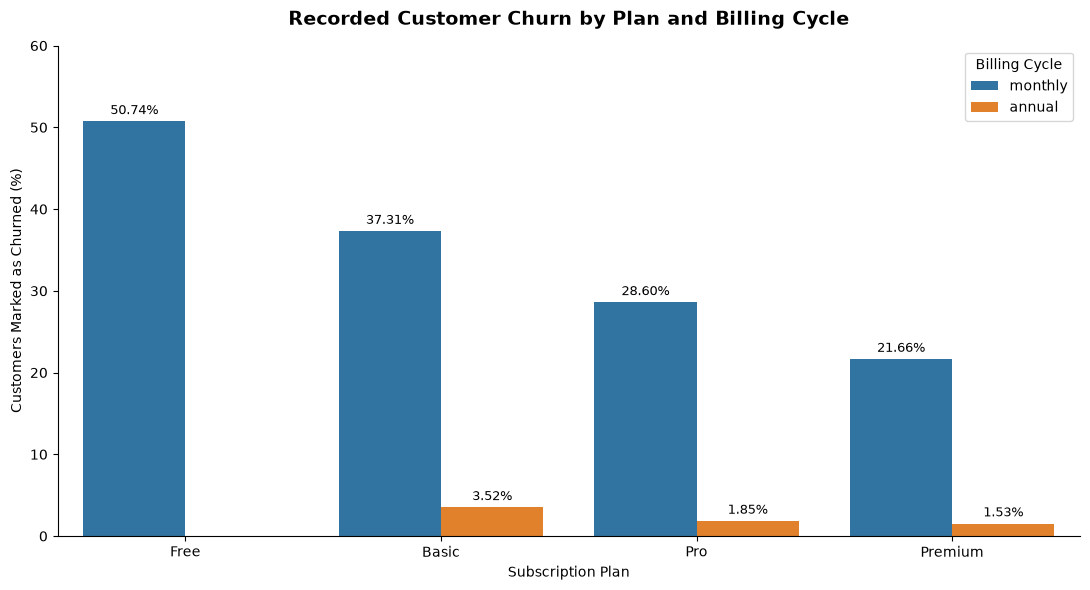

In [30]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=plan_churn,
    x="plan_name",
    y="churn_pct",
    hue="billing_cycle",
    order=["Free", "Basic", "Pro", "Premium"],
    hue_order=["monthly", "annual"],
    ax=ax
)

# Add percentage labels above the bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3,
        fontsize=9
    )

ax.set_title(
    "Recorded Customer Churn by Plan and Billing Cycle",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Subscription Plan")
ax.set_ylabel("Customers Marked as Churned (%)")
ax.set_ylim(0, 60)
ax.legend(title="Billing Cycle")

sns.despine()
plt.tight_layout()

# Save the figure
fig.savefig(
    "../outputs/figures/churn_by_subscription_plan.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 5.4 Churn Analysis by Industry

In [31]:
industry_churn = (
    customer_master
    .groupby("industry")
    .agg(
        total_customers=("customer_id", "nunique"),
        churned_customers=("is_churned", "sum")
    )
    .reset_index()
)

industry_churn["churn_pct"] = (
    industry_churn["churned_customers"]
    / industry_churn["total_customers"]
    * 100
).round(2)

industry_churn = industry_churn.sort_values(
    "churn_pct",
    ascending=False
)

display(industry_churn)

,industry,total_customers,churned_customers,churn_pct
1,health,6169,2462,39.91
3,tech,6352,2526,39.77
0,finance,6214,2396,38.56
2,retail,6265,2373,37.88


### 5.5 Visualizing Churn by Industry

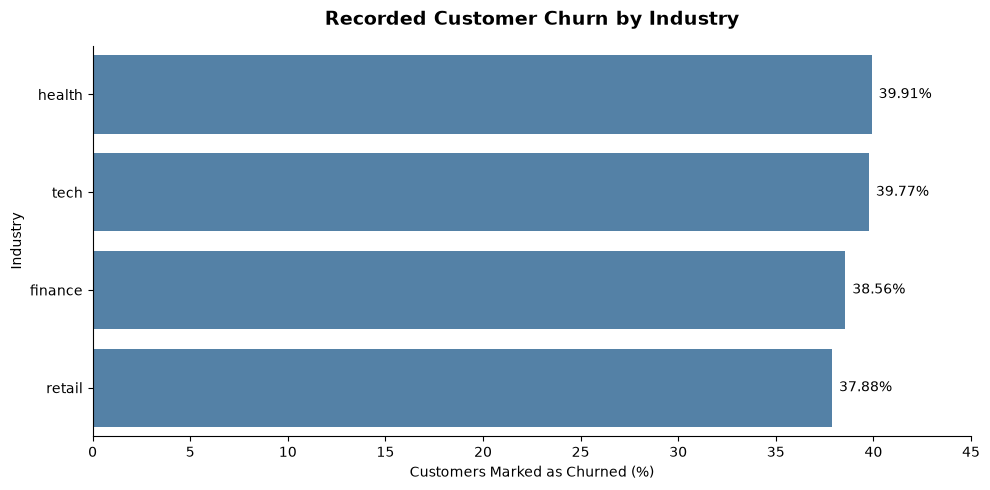

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=industry_churn,
    x="churn_pct",
    y="industry",
    order=industry_churn["industry"],
    color="steelblue",
    ax=ax
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=5
    )

ax.set_title(
    "Recorded Customer Churn by Industry",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Customers Marked as Churned (%)")
ax.set_ylabel("Industry")
ax.set_xlim(0, 45)

sns.despine()
plt.tight_layout()

fig.savefig(
    "../outputs/figures/churn_by_industry.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 5.6 Churn Analysis by Acquisition Channel

In [33]:
channel_churn = (
    customer_master
    .groupby("acquisition_channel")
    .agg(
        total_customers=("customer_id", "nunique"),
        churned_customers=("is_churned", "sum")
    )
    .reset_index()
)

channel_churn["churn_pct"] = (
    channel_churn["churned_customers"]
    / channel_churn["total_customers"]
    * 100
).round(2)

channel_churn = channel_churn.sort_values(
    "churn_pct",
    ascending=False
)

display(channel_churn)

,acquisition_channel,total_customers,churned_customers,churn_pct
2,referral,8241,3224,39.12
1,organic,8418,3287,39.05
0,ads,8341,3246,38.92


### 5.7 Visualizing Churn by Acquisition Channel

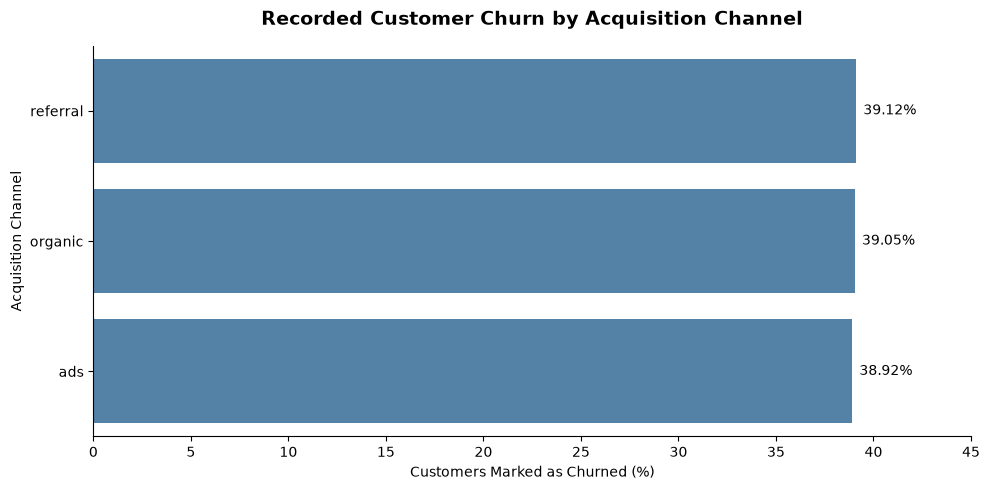

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=channel_churn,
    x="churn_pct",
    y="acquisition_channel",
    order=channel_churn["acquisition_channel"],
    color="steelblue",
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=5
    )

ax.set_title(
    "Recorded Customer Churn by Acquisition Channel",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Customers Marked as Churned (%)")
ax.set_ylabel("Acquisition Channel")
ax.set_xlim(0, 45)

sns.despine()
plt.tight_layout()

fig.savefig(
    "../outputs/figures/churn_by_acquisition_channel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 5.8 Statistical Testing: Acquisition Channel and Churn

In [35]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    customer_master["acquisition_channel"],
    customer_master["is_churned"]
)

contingency_table.columns = ["Active", "Churned"]

display(contingency_table)

,Active,Churned
acquisition_channel,,
ads,5095,3246
organic,5131,3287
referral,5017,3224


In [36]:
chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

print("\nExpected frequencies:")
display(
    pd.DataFrame(
        expected,
        index=contingency_table.index,
        columns=contingency_table.columns
    ).round(2)
)

Chi-square statistic: 0.0754
P-value: 0.963010
Degrees of freedom: 2

Expected frequencies:


,Active,Churned
acquisition_channel,,
ads,5085.67,3255.33
organic,5132.62,3285.38
referral,5024.70,3216.30


### 5.9 Statistical Testing: Industry and Churn

In [37]:
# Create the contingency table
industry_table = pd.crosstab(
    customer_master["industry"],
    customer_master["is_churned"]
)

industry_table.columns = ["Active", "Churned"]

display(industry_table)

# Perform the chi-square test
chi2_ind, p_ind, dof_ind, expected_ind = chi2_contingency(
    industry_table
)

print(f"Chi-square statistic: {chi2_ind:.4f}")
print(f"P-value: {p_ind:.6f}")
print(f"Degrees of freedom: {dof_ind}")
print(f"Minimum expected frequency: {expected_ind.min():.2f}")

,Active,Churned
industry,,
finance,3818,2396
health,3707,2462
retail,3892,2373
tech,3826,2526


Chi-square statistic: 7.5349
P-value: 0.056668
Degrees of freedom: 3
Minimum expected frequency: 2407.64


### 5.10 Statistical Testing: Subscription Plan and Churn

In [38]:
# Combine plan name and billing cycle into one category
customer_master["plan_category"] = (
    customer_master["plan_name"]
    + " - "
    + customer_master["billing_cycle"]
)

# Create the contingency table
plan_table = pd.crosstab(
    customer_master["plan_category"],
    customer_master["is_churned"]
)

plan_table.columns = ["Active", "Churned"]

display(plan_table)

# Perform chi-square test
chi2_plan, p_plan, dof_plan, expected_plan = chi2_contingency(
    plan_table
)

print(f"Chi-square statistic: {chi2_plan:.4f}")
print(f"P-value: {p_plan:.6g}")
print(f"Degrees of freedom: {dof_plan}")
print(f"Minimum expected frequency: {expected_plan.min():.2f}")

,Active,Churned
plan_category,,
Basic - annual,2054,75
Basic - monthly,3051,1816
Free - monthly,6988,7199
Premium - annual,451,7
Premium - monthly,615,170
Pro - annual,903,17
Pro - monthly,1181,473


Chi-square statistic: 2932.4561
P-value: 0
Degrees of freedom: 6
Minimum expected frequency: 178.75


### 5.11 Effect Size: Cramér's V

In [39]:
# Calculate Cramér's V
n = plan_table.to_numpy().sum()
r, c = plan_table.shape

cramers_v = np.sqrt(
    chi2_plan / (n * min(r - 1, c - 1))
)

print(f"Total observations: {n:,}")
print(f"Cramér's V: {cramers_v:.4f}")

Total observations: 25,000
Cramér's V: 0.3425


### 5.12 Statistical Analysis Summary

In [40]:
statistical_summary = pd.DataFrame({
    "Variable": [
        "Acquisition Channel",
        "Industry",
        "Subscription Plan"
    ],
    "Chi-square": [
        chi2,
        chi2_ind,
        chi2_plan
    ],
    "P-value": [
        p_value,
        p_ind,
        p_plan
    ],
    "Degrees of Freedom": [
        dof,
        dof_ind,
        dof_plan
    ]
})

statistical_summary["Cramers_V"] = [
    np.sqrt(chi2 / (25000 * 1)),
    np.sqrt(chi2_ind / (25000 * 1)),
    cramers_v
]

statistical_summary["Significant_5pct"] = (
    statistical_summary["P-value"] < 0.05
)

display(statistical_summary.round(4))

,Variable,Chi-square,P-value,Degrees of Freedom,Cramers_V,Significant_5pct
0,Acquisition Channel,0.0754,0.9630,2,0.0017,False
1,Industry,7.5349,0.0567,3,0.0174,False
2,Subscription Plan,2932.4561,0.0000,6,0.3425,True


## 6. Time-Based Churn and Retention Analysis

Analyze churn over time by examining the available observation period, completed subscription duration, monthly churn events, and monthly churn rates.
### 6.1 Dataset Date Range

In [41]:
date_ranges = {
    "Customer signups": customers["signup_date"],
    "Subscription starts": subscriptions["start_date"],
    "Subscription ends": subscriptions["end_date"],
    "Payments": payments["payment_date"],
    "Invoices": invoices["invoice_date"],
    "Churn events": churn_events["churn_date"]
}

for name, dates in date_ranges.items():
    print(f"\n{name}")
    print(f"Earliest: {dates.min().date()}")
    print(f"Latest:   {dates.max().date()}")
    print(f"Records:  {dates.notna().sum():,}")


Customer signups
Earliest: 2023-01-01
Latest:   2025-12-31
Records:  25,000

Subscription starts
Earliest: 2023-01-01
Latest:   2025-12-31
Records:  25,000

Subscription ends
Earliest: 2023-02-01
Latest:   2025-12-30
Records:  9,757

Payments
Earliest: 2023-01-01
Latest:   2025-11-30
Records:  68,411

Invoices
Earliest: 2023-01-01
Latest:   2025-11-30
Records:  68,411

Churn events
Earliest: 2023-02-01
Latest:   2025-12-30
Records:  9,757


### 6.2 Subscription Duration Analysis

In [42]:
# Create a separate DataFrame for churned customers
churned_customers_df = customer_master[
    customer_master["is_churned"] == 1
].copy()

# Calculate completed subscription duration
churned_customers_df["duration_days"] = (
    churned_customers_df["end_date"]
    - churned_customers_df["start_date"]
).dt.days

# Display summary statistics
display(
    churned_customers_df["duration_days"].describe().round(2)
)

# Check for invalid durations
print(
    "Negative durations:",
    (churned_customers_df["duration_days"] < 0).sum()
)

print(
    "Missing durations:",
    churned_customers_df["duration_days"].isna().sum()
)

count    9757.00
mean      241.48
std       194.26
min        28.00
25%        92.00
50%       184.00
75%       336.00
max      1065.00
Name: duration_days, dtype: float64

Negative durations: 0
Missing durations: 0


### 6.3 Distribution of Completed Subscription Durations

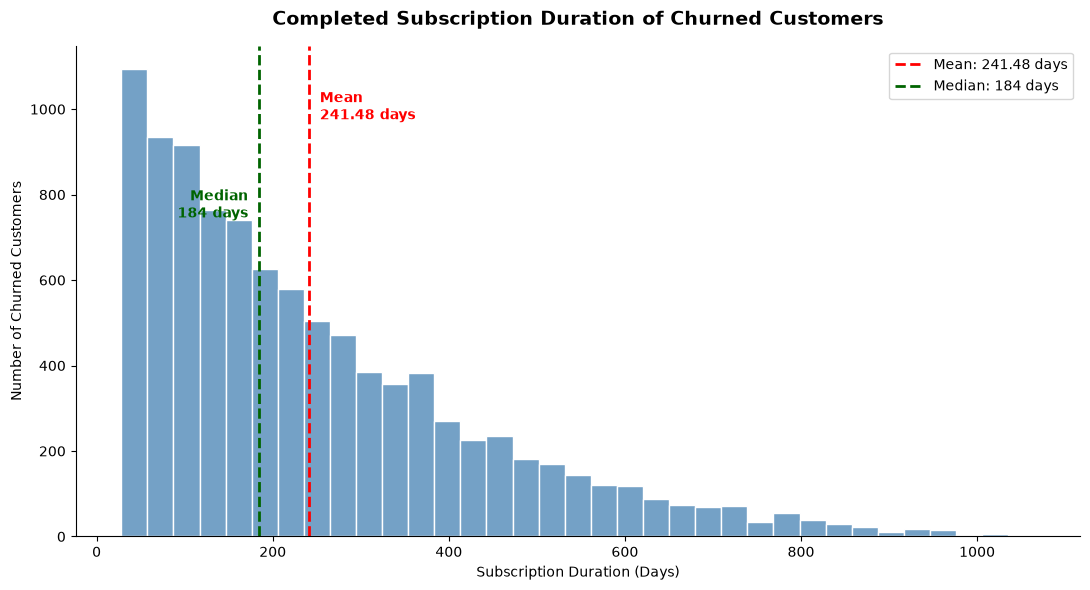

In [43]:
fig, ax = plt.subplots(figsize=(11, 6))

mean_duration = churned_customers_df["duration_days"].mean()
median_duration = churned_customers_df["duration_days"].median()

# Plot the histogram
sns.histplot(
    data=churned_customers_df,
    x="duration_days",
    bins=35,
    color="steelblue",
    edgecolor="white",
    ax=ax
)

# Add mean and median reference lines
ax.axvline(
    mean_duration,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_duration:.2f} days"
)

ax.axvline(
    median_duration,
    color="darkgreen",
    linestyle="--",
    linewidth=2,
    label=f"Median: {median_duration:.0f} days"
)

# Add labels beside the reference lines
ymax = ax.get_ylim()[1]

ax.text(
    mean_duration + 12,
    ymax * 0.85,
    f"Mean\n{mean_duration:.2f} days",
    color="red",
    fontsize=10,
    fontweight="bold"
)

ax.text(
    median_duration - 12,
    ymax * 0.65,
    f"Median\n{median_duration:.0f} days",
    color="darkgreen",
    fontsize=10,
    fontweight="bold",
    ha="right"
)

ax.set_title(
    "Completed Subscription Duration of Churned Customers",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Subscription Duration (Days)")
ax.set_ylabel("Number of Churned Customers")
ax.legend(loc="upper right")

sns.despine()
plt.tight_layout()

fig.savefig(
    "../outputs/figures/churned_subscription_duration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 6.4 Monthly Churn Events

In [44]:
monthly_churn = (
    churn_events
    .assign(
        churn_month=churn_events["churn_date"].dt.to_period("M")
    )
    .groupby("churn_month")
    .agg(
        churned_customers=("customer_id", "nunique")
    )
    .reset_index()
)

monthly_churn["churn_month"] = (
    monthly_churn["churn_month"].dt.to_timestamp()
)

print(
    "Total churn events:",
    monthly_churn["churned_customers"].sum()
)

display(monthly_churn.head(10))
display(monthly_churn.tail(5))

Total churn events: 9757


,churn_month,churned_customers
0,2023-02-01,18
1,2023-03-01,37
2,2023-04-01,43
3,2023-05-01,69
4,2023-06-01,93
5,2023-07-01,84
6,2023-08-01,111
7,2023-09-01,133
8,2023-10-01,144
9,2023-11-01,145


,churn_month,churned_customers
30,2025-08-01,456
31,2025-09-01,546
32,2025-10-01,556
33,2025-11-01,532
34,2025-12-01,512


### 6.5 Monthly Customer Churn Rate

In [45]:
# Create a monthly calendar
months = pd.date_range(
    start="2023-02-01",
    end="2025-12-01",
    freq="MS"
)

monthly_base = []

for month_start in months:

    # Customers subscribed before the month began
    # who had not churned before that month
    active_at_start = (
        (customer_master["start_date"] < month_start)
        &
        (
            customer_master["end_date"].isna()
            | (customer_master["end_date"] >= month_start)
        )
    )

    monthly_base.append({
        "month": month_start,
        "opening_customers": active_at_start.sum()
    })

monthly_base = pd.DataFrame(monthly_base)

display(monthly_base.head(10))
display(monthly_base.tail(5))

,month,opening_customers
0,2023-02-01,399
1,2023-03-01,737
2,2023-04-01,1145
3,2023-05-01,1525
4,2023-06-01,1861
5,2023-07-01,2173
6,2023-08-01,2534
7,2023-09-01,2839
8,2023-10-01,3133
9,2023-11-01,3405


,month,opening_customers
30,2025-08-01,12788
31,2025-09-01,13335
32,2025-10-01,13787
33,2025-11-01,14254
34,2025-12-01,14699


### 6.5.1 Churn Date Consistency Check

In [46]:
# Compare subscription end dates with recorded churn-event dates
churn_date_check = (
    subscriptions[
        subscriptions["status"] == "churned"
    ][["subscription_id", "customer_id", "end_date"]]
    .merge(
        churn_events[["customer_id", "churn_date"]],
        on="customer_id",
        how="left",
        validate="one_to_one"
    )
)

# Check whether the two dates match
churn_date_check["dates_match"] = (
    churn_date_check["end_date"]
    == churn_date_check["churn_date"]
)

print("Total churned subscriptions:",
      len(churn_date_check))

print(
    "Matching dates:",
    churn_date_check["dates_match"].sum()
)

print(
    "Non-matching dates:",
    (~churn_date_check["dates_match"]).sum()
)

display(
    churn_date_check[
        ~churn_date_check["dates_match"]
    ].head(10)
)

Total churned subscriptions: 9757
Matching dates: 9757
Non-matching dates: 0


,subscription_id,customer_id,end_date,churn_date,dates_match


In [47]:
# Combine opening customer base with monthly churn counts
monthly_churn_rate = monthly_base.merge(
    monthly_churn,
    left_on="month",
    right_on="churn_month",
    how="left"
)

# Remove duplicate date column
monthly_churn_rate = monthly_churn_rate.drop(
    columns="churn_month"
)

# Calculate monthly churn rate
monthly_churn_rate["churn_rate_pct"] = (
    monthly_churn_rate["churned_customers"]
    / monthly_churn_rate["opening_customers"]
    * 100
).round(2)

display(monthly_churn_rate.head(10))
display(monthly_churn_rate.tail(5))

,month,opening_customers,churned_customers,churn_rate_pct
0,2023-02-01,399,18,4.51
1,2023-03-01,737,37,5.02
2,2023-04-01,1145,43,3.76
3,2023-05-01,1525,69,4.52
4,2023-06-01,1861,93,5.00
5,2023-07-01,2173,84,3.87
6,2023-08-01,2534,111,4.38
7,2023-09-01,2839,133,4.68
8,2023-10-01,3133,144,4.60
9,2023-11-01,3405,145,4.26


,month,opening_customers,churned_customers,churn_rate_pct
30,2025-08-01,12788,456,3.57
31,2025-09-01,13335,546,4.09
32,2025-10-01,13787,556,4.03
33,2025-11-01,14254,532,3.73
34,2025-12-01,14699,512,3.48


### 6.6 Monthly Churn Rate Trend

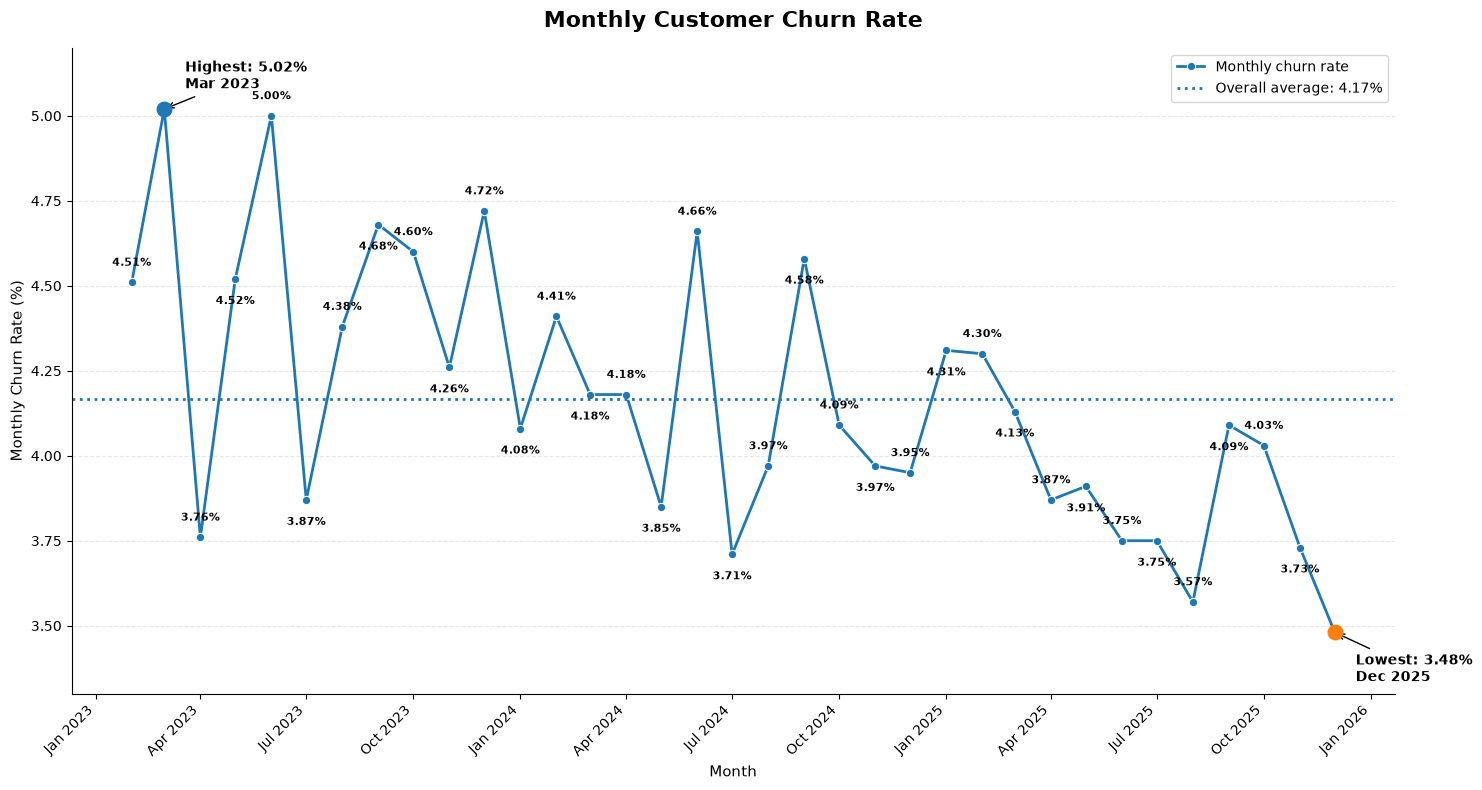

In [48]:
# Calculate key statistics
average_churn_rate = monthly_churn_rate["churn_rate_pct"].mean()

max_idx = monthly_churn_rate["churn_rate_pct"].idxmax()
min_idx = monthly_churn_rate["churn_rate_pct"].idxmin()

max_month = monthly_churn_rate.loc[max_idx, "month"]
max_rate = monthly_churn_rate.loc[max_idx, "churn_rate_pct"]

min_month = monthly_churn_rate.loc[min_idx, "month"]
min_rate = monthly_churn_rate.loc[min_idx, "churn_rate_pct"]

fig, ax = plt.subplots(figsize=(15, 8))

# Monthly churn rate
sns.lineplot(
    data=monthly_churn_rate,
    x="month",
    y="churn_rate_pct",
    marker="o",
    linewidth=2,
    markersize=6,
    label="Monthly churn rate",
    ax=ax
)

# Overall average
ax.axhline(
    average_churn_rate,
    linestyle=":",
    linewidth=2,
    label=f"Overall average: {average_churn_rate:.2f}%"
)

# Add percentage labels
for i, row in monthly_churn_rate.iterrows():

    offset = 12 if i % 2 == 0 else -18

    # Avoid duplicating the labels for highest/lowest points
    if i not in [max_idx, min_idx]:
        ax.annotate(
            f"{row['churn_rate_pct']:.2f}%",
            xy=(row["month"], row["churn_rate_pct"]),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            fontsize=8,
            fontweight="bold"
        )

# Highlight highest month
ax.scatter(
    max_month,
    max_rate,
    s=110,
    zorder=5
)

ax.annotate(
    f"Highest: {max_rate:.2f}%\n{max_month:%b %Y}",
    xy=(max_month, max_rate),
    xytext=(15, 15),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->")
)

# Highlight lowest month
ax.scatter(
    min_month,
    min_rate,
    s=110,
    zorder=5
)

ax.annotate(
    f"Lowest: {min_rate:.2f}%\n{min_month:%b %Y}",
    xy=(min_month, min_rate),
    xytext=(15, -35),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->")
)

# Titles and labels
ax.set_title(
    "Monthly Customer Churn Rate",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Monthly Churn Rate (%)", fontsize=11)

# X-axis formatting
ax.xaxis.set_major_locator(
    plt.matplotlib.dates.MonthLocator(interval=3)
)

ax.xaxis.set_major_formatter(
    plt.matplotlib.dates.DateFormatter("%b %Y")
)

plt.xticks(rotation=45, ha="right")

# Y-axis
ax.set_ylim(3.3, 5.2)

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

sns.despine()

ax.legend(
    loc="upper right",
    frameon=True
)

plt.tight_layout()

# Save final version
fig.savefig(
    "../outputs/figures/monthly_churn_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7. Cohort Retention Analysis

Analyze customer retention by signup cohort and subscription age to understand how retention changes over time and how different customer cohorts progress through their observed subscription lifecycle.

### 7.1 Customer Signup Cohorts

In [49]:
# Create signup month for each customer
customer_master["signup_month"] = (
    customer_master["signup_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# Summarize cohort sizes
cohort_sizes = (
    customer_master
    .groupby("signup_month")
    .agg(
        cohort_customers=("customer_id", "nunique")
    )
    .reset_index()
    .sort_values("signup_month")
)

display(cohort_sizes)

,signup_month,cohort_customers
0,2023-01-01,399
1,2023-02-01,356
2,2023-03-01,445
3,2023-04-01,423
4,2023-05-01,405
5,2023-06-01,405
6,2023-07-01,445
7,2023-08-01,416
8,2023-09-01,427
9,2023-10-01,416


### 7.2 Observed Subscription Tenure

In [50]:
# Dataset observation cutoff
observation_cutoff = pd.Timestamp("2025-12-31")

# Use actual end date for churned customers
# Use the observation cutoff for active customers
customer_master["observed_end_date"] = (
    customer_master["end_date"]
    .fillna(observation_cutoff)
)

# Calculate completed subscription months
year_diff = (
    customer_master["observed_end_date"].dt.year
    - customer_master["signup_date"].dt.year
)

month_diff = (
    customer_master["observed_end_date"].dt.month
    - customer_master["signup_date"].dt.month
)

customer_master["tenure_months"] = (
    year_diff * 12
    + month_diff
    - (
        customer_master["observed_end_date"].dt.day
        < customer_master["signup_date"].dt.day
    ).astype(int)
)

display(
    customer_master[
        [
            "customer_id",
            "signup_date",
            "status",
            "end_date",
            "observed_end_date",
            "tenure_months"
        ]
    ].head(10)
)

print("\nTenure summary:")
display(
    customer_master["tenure_months"]
    .describe()
    .round(2)
)

print(
    "\nNegative tenure values:",
    (customer_master["tenure_months"] < 0).sum()
)

,customer_id,signup_date,status,end_date,observed_end_date,tenure_months
0,1,2023-05-11,active,NaT,2025-12-31,31
1,2,2023-04-25,churned,2023-11-25,2023-11-25,7
2,3,2023-03-18,active,NaT,2025-12-31,33
3,4,2023-05-08,churned,2023-10-08,2023-10-08,5
4,5,2023-05-28,churned,2023-11-28,2023-11-28,6
5,6,2023-04-16,churned,2024-01-16,2024-01-16,9
6,7,2023-09-16,churned,2025-01-16,2025-01-16,16
7,8,2023-02-12,churned,2024-05-12,2024-05-12,15
8,9,2023-10-13,active,NaT,2025-12-31,26
9,10,2023-01-31,churned,2024-03-28,2024-03-28,13



Tenure summary:


count    25000.00
mean         9.70
std          8.25
min          0.00
25%          3.00
50%          7.00
75%         14.00
max         35.00
Name: tenure_months, dtype: float64


Negative tenure values: 0


### 7.3 Cohort Retention Matrix

In [51]:
# Maximum observable cohort age
customer_master["max_observable_months"] = (
    (
        observation_cutoff.to_period("M")
        - customer_master["signup_month"].dt.to_period("M")
    ).apply(lambda x: x.n)
)

# Cohort sizes
cohort_sizes = (
    customer_master
    .groupby("signup_month")["customer_id"]
    .nunique()
)

# Retention results
retention_matrix = pd.DataFrame(
    index=cohort_sizes.index
)

# Calculate retention for each cohort age
for month in range(36):

    retained = (
        customer_master["tenure_months"] >= month
    )

    retained_counts = (
        customer_master[retained]
        .groupby("signup_month")["customer_id"]
        .nunique()
    )

    retention_matrix[month] = (
        retained_counts
        .reindex(cohort_sizes.index, fill_value=0)
        / cohort_sizes
        * 100
    )

# Label the columns
retention_matrix.columns = [
    f"Month {month}" for month in retention_matrix.columns
]

# Hide periods that were not yet observable
for cohort in retention_matrix.index:

    max_month = (
        observation_cutoff.to_period("M")
        - cohort.to_period("M")
    ).n

    for month in range(max_month + 1, 36):
        retention_matrix.loc[
            cohort, f"Month {month}"
        ] = np.nan

retention_matrix = retention_matrix.round(2)

display(retention_matrix)

,Month 0,Month 1,Month 2,Month 3,Month 4,Month 5,Month 6,Month 7,Month 8,Month 9,...,Month 26,Month 27,Month 28,Month 29,Month 30,Month 31,Month 32,Month 33,Month 34,Month 35
signup_month,,,,,,,,,,,,,,,,,,,,,
2023-01-01,100.0,99.25,94.99,90.73,86.72,80.70,77.19,74.19,70.18,66.67,...,33.58,32.83,32.33,31.83,30.58,30.08,29.07,28.07,27.07,26.57
2023-02-01,100.0,100.00,94.10,91.01,87.92,83.71,79.78,76.40,74.16,70.79,...,39.33,37.92,37.36,36.80,35.96,35.67,33.99,32.87,32.87,NaN
2023-03-01,100.0,99.55,96.63,93.93,88.31,84.94,80.90,77.98,74.61,72.13,...,41.57,39.55,37.30,35.73,35.51,35.06,34.61,33.71,NaN,NaN
2023-04-01,100.0,100.00,94.33,89.36,86.76,83.92,80.38,76.83,73.52,70.45,...,40.19,38.06,37.35,37.12,36.17,35.46,34.99,NaN,NaN,NaN
2023-05-01,100.0,100.00,95.80,92.84,88.64,84.44,80.25,75.31,72.10,69.14,...,34.57,33.58,33.33,32.84,32.10,31.85,NaN,NaN,NaN,NaN
2023-06-01,100.0,100.00,95.06,89.63,83.70,78.02,74.81,70.86,68.89,64.94,...,38.52,38.02,37.04,35.56,34.57,NaN,NaN,NaN,NaN,NaN
2023-07-01,100.0,100.00,96.40,92.13,89.21,86.07,81.35,77.75,75.06,72.13,...,41.57,40.67,39.33,38.65,NaN,NaN,NaN,NaN,NaN,NaN
2023-08-01,100.0,99.76,95.19,91.35,87.26,82.93,78.61,75.24,72.60,69.23,...,39.90,39.42,37.74,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-01,100.0,100.00,95.08,90.63,87.59,84.54,81.50,77.75,74.71,72.83,...,41.22,38.88,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
# Check that every cohort starts at 100%
month_0_check = retention_matrix["Month 0"]

print("Month 0 retention:")
print(month_0_check.unique())

print(
    "\nCohorts with Month 0 != 100%:",
    (month_0_check != 100).sum()
)

# Check that retention never increases within a cohort
monotonic_violations = 0

for cohort in retention_matrix.index:
    values = retention_matrix.loc[cohort].dropna().values

    if (np.diff(values) > 0).any():
        monotonic_violations += 1

print(
    "Cohorts with increasing retention:",
    monotonic_violations
)

Month 0 retention:
[100.]

Cohorts with Month 0 != 100%: 0
Cohorts with increasing retention: 0


### 7.4 Cohort Retention Heatmap

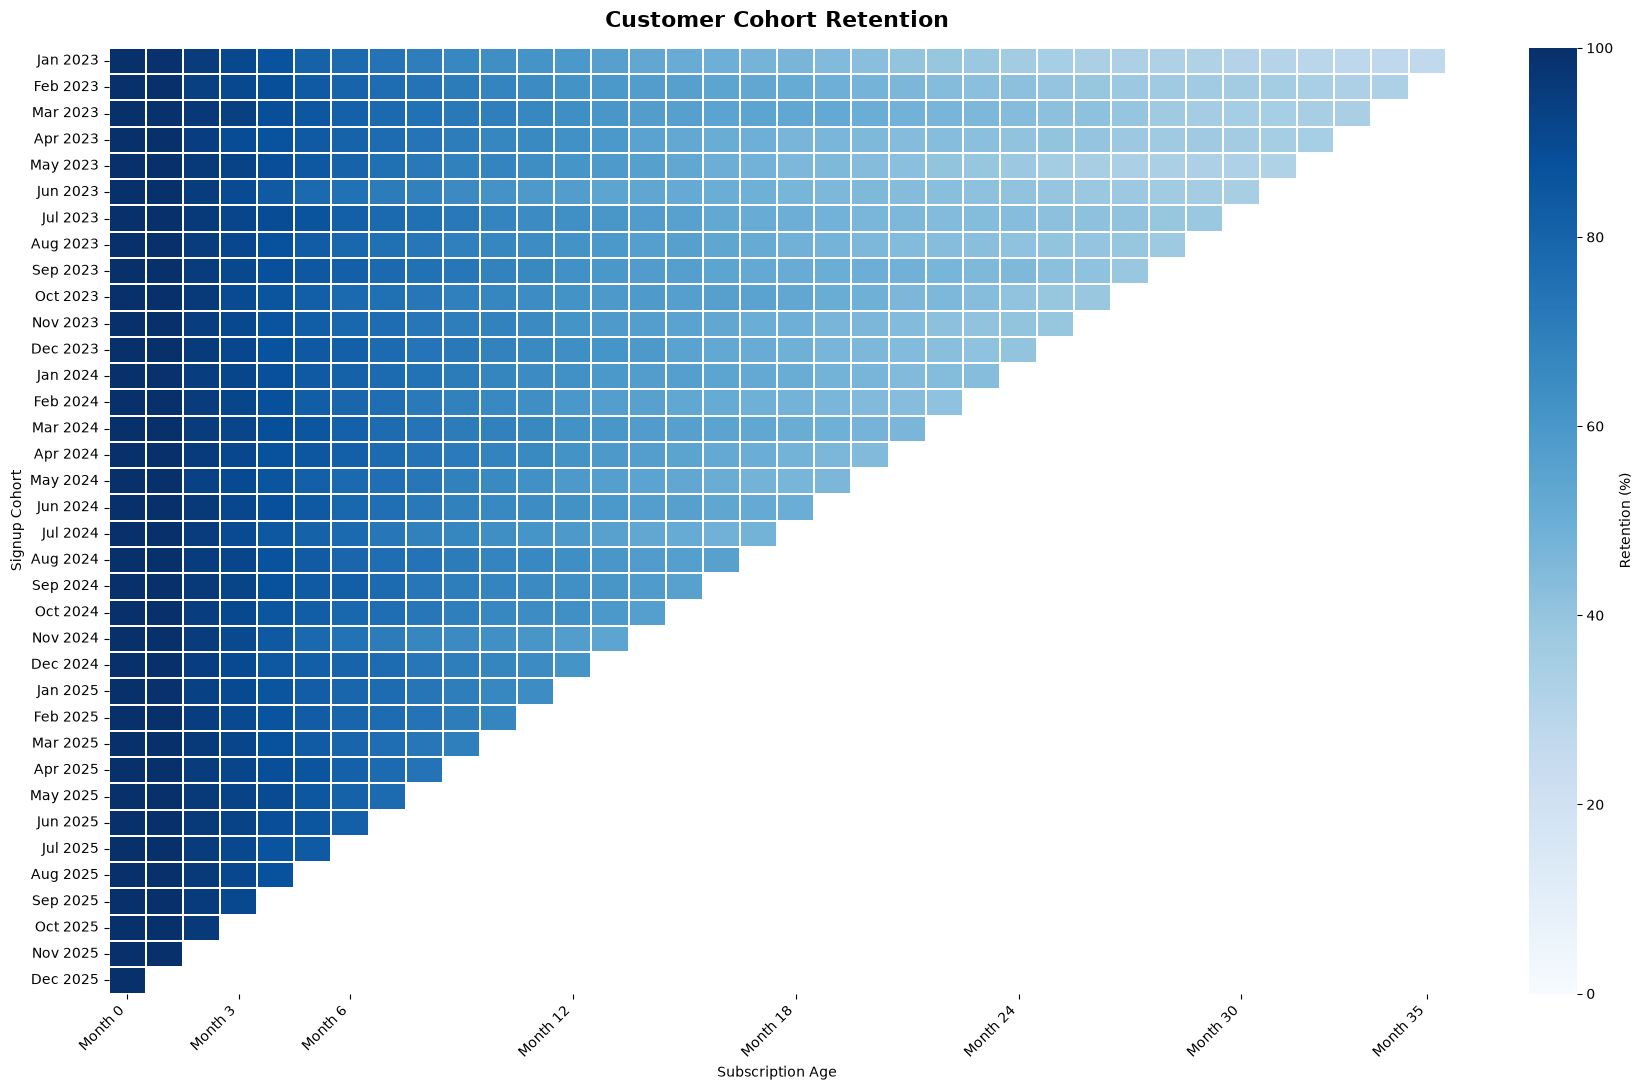

In [53]:
# Create a copy only for visualization
heatmap_data = retention_matrix.copy()

# Convert cohort dates to readable labels
heatmap_data.index = heatmap_data.index.strftime("%b %Y")

fig, ax = plt.subplots(figsize=(18, 11))

sns.heatmap(
    heatmap_data,
    annot=False,
    cmap="Blues",
    vmin=0,
    vmax=100,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Retention (%)"},
    ax=ax
)

ax.set_title(
    "Customer Cohort Retention",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Subscription Age")
ax.set_ylabel("Signup Cohort")

# Selected tenure checkpoints
selected_months = [0, 3, 6, 12, 18, 24, 30, 35]

ax.set_xticks(
    [m + 0.5 for m in selected_months]
)

ax.set_xticklabels(
    [f"Month {m}" for m in selected_months],
    rotation=45,
    ha="right"
)

# Clean y-axis labels
ax.set_yticklabels(
    heatmap_data.index,
    rotation=0
)

plt.tight_layout()

fig.savefig(
    "../outputs/figures/cohort_retention_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 7.5 Key Cohort Retention Checkpoints

In [54]:
# Select key retention checkpoints
retention_checkpoints = retention_matrix[
    ["Month 1", "Month 3", "Month 6", "Month 12"]
].copy()

# Convert cohort dates into readable labels
retention_checkpoints.index = (
    retention_checkpoints.index.strftime("%b %Y")
)

display(retention_checkpoints)

,Month 1,Month 3,Month 6,Month 12
signup_month,,,,
Jan 2023,99.25,90.73,77.19,59.40
Feb 2023,100.00,91.01,79.78,62.08
Mar 2023,99.55,93.93,80.90,63.37
Apr 2023,100.00,89.36,80.38,62.88
May 2023,100.00,92.84,80.25,61.23
Jun 2023,100.00,89.63,74.81,57.78
Jul 2023,100.00,92.13,81.35,63.15
Aug 2023,99.76,91.35,78.61,62.02
Sep 2023,100.00,90.63,81.50,62.76


In [55]:
checkpoint_summary = pd.DataFrame({
    "Checkpoint": [
        "Month 1",
        "Month 3",
        "Month 6",
        "Month 12"
    ],
    "Average Retention (%)": [
        retention_matrix["Month 1"].mean(),
        retention_matrix["Month 3"].mean(),
        retention_matrix["Month 6"].mean(),
        retention_matrix["Month 12"].mean()
    ],
    "Median Retention (%)": [
        retention_matrix["Month 1"].median(),
        retention_matrix["Month 3"].median(),
        retention_matrix["Month 6"].median(),
        retention_matrix["Month 12"].median()
    ],
    "Observable Cohorts": [
        retention_matrix["Month 1"].notna().sum(),
        retention_matrix["Month 3"].notna().sum(),
        retention_matrix["Month 6"].notna().sum(),
        retention_matrix["Month 12"].notna().sum()
    ]
})

checkpoint_summary[
    ["Average Retention (%)", "Median Retention (%)"]
] = checkpoint_summary[
    ["Average Retention (%)", "Median Retention (%)"]
].round(2)

display(checkpoint_summary)

,Checkpoint,Average Retention (%),Median Retention (%),Observable Cohorts
0,Month 1,99.89,100.00,35
1,Month 3,91.17,91.09,33
2,Month 6,79.50,79.68,30
3,Month 12,61.64,62.06,24


### 7.6 Average Cohort Retention by Subscription Age

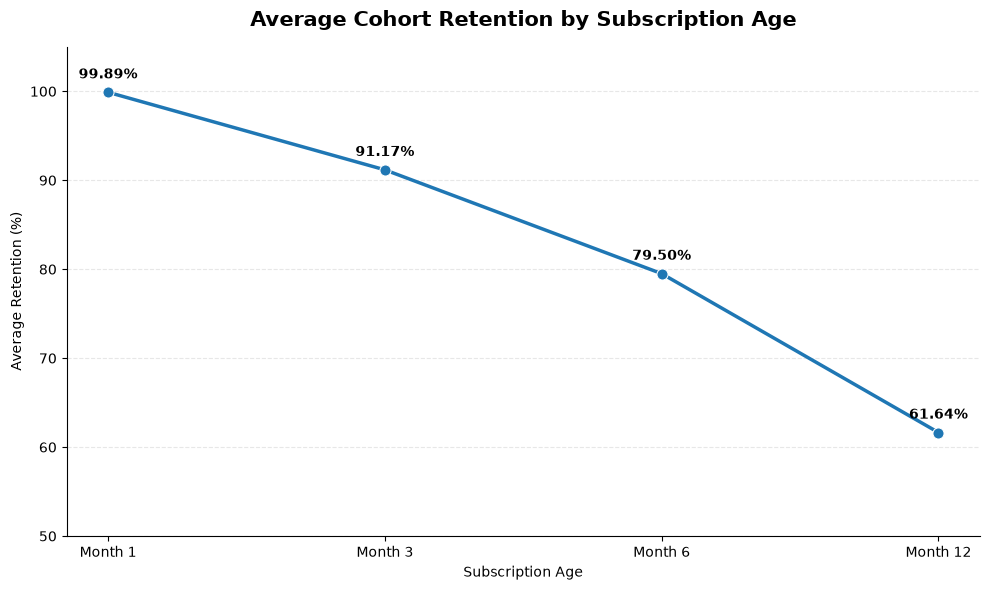

In [56]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=checkpoint_summary,
    x="Checkpoint",
    y="Average Retention (%)",
    marker="o",
    linewidth=2.5,
    markersize=8,
    ax=ax
)

# Add percentage labels
for _, row in checkpoint_summary.iterrows():
    ax.annotate(
        f"{row['Average Retention (%)']:.2f}%",
        xy=(row["Checkpoint"], row["Average Retention (%)"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "Average Cohort Retention by Subscription Age",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Subscription Age")
ax.set_ylabel("Average Retention (%)")

ax.set_ylim(50, 105)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

sns.despine()

plt.tight_layout()

fig.savefig(
    "../outputs/figures/cohort_retention_checkpoints.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. Revenue Analysis

Analyze invoiced revenue, payment outcomes, monthly revenue trends, revenue contribution by subscription plan, and customer-level monetization patterns.

### 8.1 Invoice and Payment Status

In [57]:
print("INVOICE STATUS")
display(
    invoices["status"].value_counts(dropna=False)
)

print("\nPAYMENT STATUS")
display(
    payments["status"].value_counts(dropna=False)
)

INVOICE STATUS


status
paid    68411
Name: count, dtype: int64


PAYMENT STATUS


status
successful    63614
failed         4797
Name: count, dtype: int64

### 8.2 Core Revenue Metrics

In [58]:
# Revenue from invoices
invoiced_revenue = invoices["amount"].sum()

# Revenue from successful payments
successful_payment_revenue = payments.loc[
    payments["status"] == "successful",
    "amount"
].sum()

# Amount associated with failed payments
failed_payment_amount = payments.loc[
    payments["status"] == "failed",
    "amount"
].sum()

# Payment success rate by transaction count
payment_success_rate = (
    (payments["status"] == "successful").sum()
    / len(payments)
    * 100
)

print(f"Invoiced Revenue: ₹{invoiced_revenue:,.2f}")
print(
    f"Successful Payment Revenue: "
    f"₹{successful_payment_revenue:,.2f}"
)
print(
    f"Failed Payment Amount: "
    f"₹{failed_payment_amount:,.2f}"
)
print(
    f"Payment Success Rate: "
    f"{payment_success_rate:.2f}%"
)

Invoiced Revenue: ₹3,462,189.00
Successful Payment Revenue: ₹3,221,429.00
Failed Payment Amount: ₹240,760.00
Payment Success Rate: 92.99%


In [59]:
payment_summary = (
    payments
    .groupby("status")
    .agg(
        transactions=("payment_id", "count"),
        total_amount=("amount", "sum"),
        average_amount=("amount", "mean")
    )
    .reset_index()
)

payment_summary["total_amount"] = (
    payment_summary["total_amount"].round(2)
)

payment_summary["average_amount"] = (
    payment_summary["average_amount"].round(2)
)

display(payment_summary)

,status,transactions,total_amount,average_amount
0,failed,4797,240760.0,50.19
1,successful,63614,3221429.0,50.64


### 8.3 Monthly Invoiced Revenue

In [60]:
monthly_revenue = (
    invoices
    .assign(
        invoice_month=invoices["invoice_date"].dt.to_period("M")
    )
    .groupby("invoice_month")
    .agg(
        invoiced_revenue=("amount", "sum"),
        invoices=("invoice_id", "nunique")
    )
    .reset_index()
)

monthly_revenue["invoice_month"] = (
    monthly_revenue["invoice_month"].dt.to_timestamp()
)

monthly_revenue["invoiced_revenue"] = (
    monthly_revenue["invoiced_revenue"].round(2)
)

display(monthly_revenue.head(10))
display(monthly_revenue.tail(5))

print(
    "Total monthly revenue:",
    f"₹{monthly_revenue['invoiced_revenue'].sum():,.2f}"
)

,invoice_month,invoiced_revenue,invoices
0,2023-01-01,21894.0,159
1,2023-02-01,25644.0,250
2,2023-03-01,35751.0,389
3,2023-04-01,36697.0,500
4,2023-05-01,38795.0,591
5,2023-06-01,49929.0,694
6,2023-07-01,47744.0,780
7,2023-08-01,47354.0,861
8,2023-09-01,54726.0,935
9,2023-10-01,58439.0,1002


,invoice_month,invoiced_revenue,invoices
30,2025-07-01,135280.0,3450
31,2025-08-01,143182.0,3618
32,2025-09-01,147445.0,3715
33,2025-10-01,152013.0,3827
34,2025-11-01,155676.0,3914


Total monthly revenue: ₹3,462,189.00


**Month-over-month growth:** Shows the percentage change in invoiced revenue compared with the previous month.

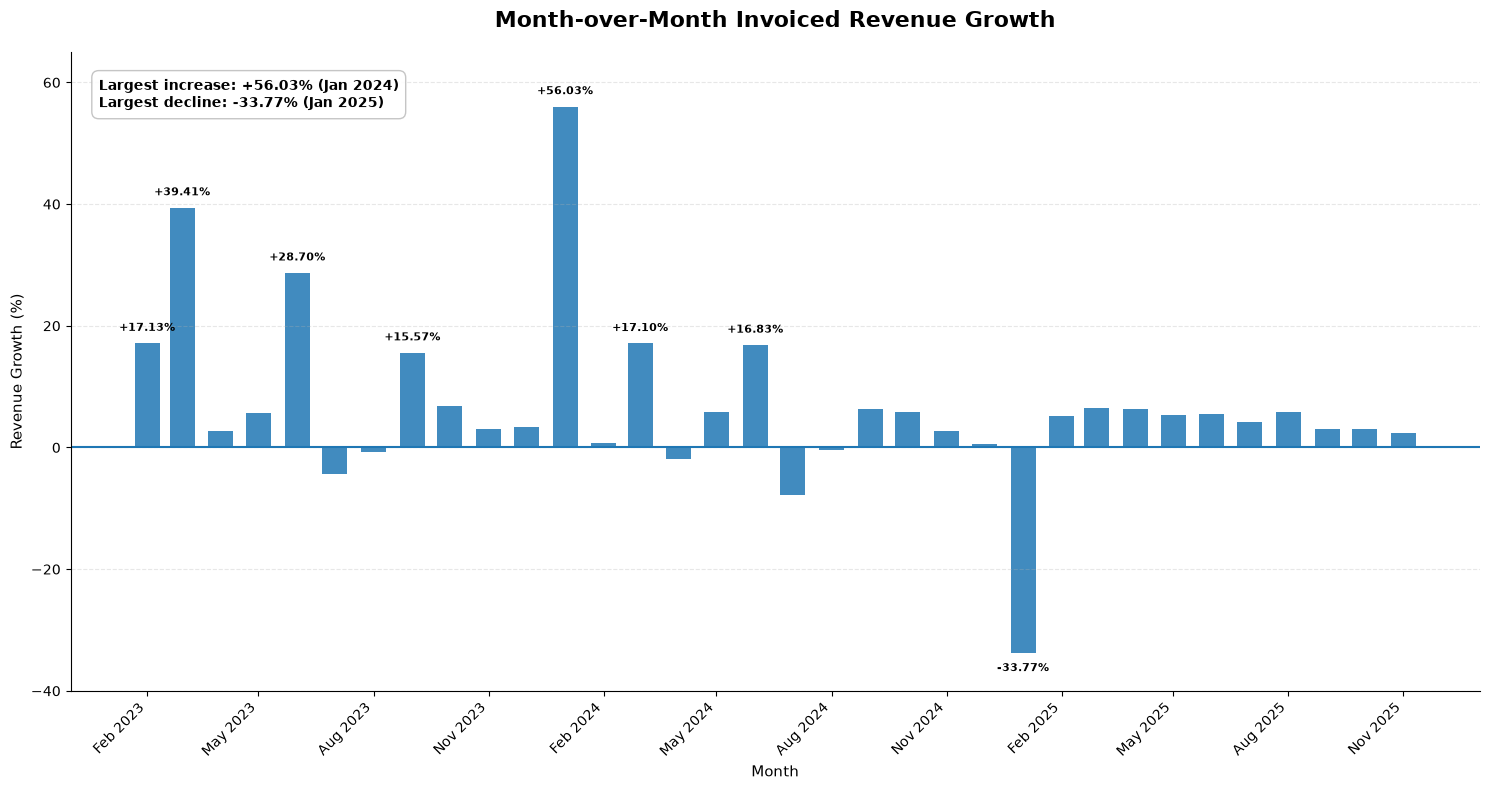

Largest monthly increase: +56.03% (January 2024)
Largest monthly decline: -33.77% (January 2025)


In [61]:
import matplotlib.dates as mdates

# Calculate month-over-month revenue growth
monthly_revenue["mom_growth_pct"] = (
    monthly_revenue["invoiced_revenue"]
    .pct_change()
    * 100
)

# Round for presentation
monthly_revenue["mom_growth_pct"] = (
    monthly_revenue["mom_growth_pct"].round(2)
)

# Exclude January 2023 because MoM growth is undefined
mom_plot = monthly_revenue.dropna(
    subset=["mom_growth_pct"]
).copy()

# Identify largest increase and decline
max_growth_idx = mom_plot["mom_growth_pct"].idxmax()
min_growth_idx = mom_plot["mom_growth_pct"].idxmin()

max_growth_month = mom_plot.loc[
    max_growth_idx, "invoice_month"
]
max_growth = mom_plot.loc[
    max_growth_idx, "mom_growth_pct"
]

min_growth_month = mom_plot.loc[
    min_growth_idx, "invoice_month"
]
min_growth = mom_plot.loc[
    min_growth_idx, "mom_growth_pct"
]

# ---------------------------------------------------------
# Create figure
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(15, 8))

# Plot monthly MoM growth
ax.bar(
    mom_plot["invoice_month"],
    mom_plot["mom_growth_pct"],
    width=20,
    alpha=0.85
)

# Zero reference line
ax.axhline(
    0,
    linewidth=1.5
)

# Label only meaningful movements
for _, row in mom_plot.iterrows():

    value = row["mom_growth_pct"]

    if abs(value) >= 10:

        offset = 7 if value >= 0 else -7
        va = "bottom" if value >= 0 else "top"

        ax.annotate(
            f"{value:+.2f}%",
            xy=(row["invoice_month"], value),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            va=va,
            fontsize=8,
            fontweight="bold"
        )

# Summary box
summary_text = (
    f"Largest increase: +{max_growth:.2f}% "
    f"({max_growth_month:%b %Y})\n"
    f"Largest decline: {min_growth:.2f}% "
    f"({min_growth_month:%b %Y})"
)

ax.text(
    0.02,
    0.96,
    summary_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="0.75",
        alpha=0.9
    )
)

# Titles and labels
ax.set_title(
    "Month-over-Month Invoiced Revenue Growth",
    fontsize=16,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Month",
    fontsize=11
)

ax.set_ylabel(
    "Revenue Growth (%)",
    fontsize=11
)

# Datetime axis
ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

plt.xticks(
    rotation=45,
    ha="right"
)

# Y-axis
ax.set_ylim(
    min(mom_plot["mom_growth_pct"].min() - 5, -40),
    max(mom_plot["mom_growth_pct"].max() + 8, 65)
)

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

sns.despine()

plt.tight_layout()

# Save
fig.savefig(
    "../outputs/figures/monthly_revenue_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Largest monthly increase: "
    f"+{max_growth:.2f}% "
    f"({max_growth_month:%B %Y})"
)

print(
    f"Largest monthly decline: "
    f"{min_growth:.2f}% "
    f"({min_growth_month:%B %Y})"
)

### 8.3.1 Revenue Change Diagnostics

Investigate notable month-over-month revenue movements by comparing January revenue with the preceding December and examining invoice composition by billing cycle.

In [62]:
# Compare January revenue with the preceding December
january_analysis = monthly_revenue[
    monthly_revenue["invoice_month"].dt.month == 1
][
    [
        "invoice_month",
        "invoiced_revenue",
        "mom_growth_pct"
    ]
].copy()

display(january_analysis)

,invoice_month,invoiced_revenue,mom_growth_pct
0,2023-01-01,21894.0,NaN
12,2024-01-01,97074.0,56.03
24,2025-01-01,98051.0,-33.77


In [63]:
# Examine invoice composition by billing cycle for January months

# Create the required invoice-level plan dataset locally
january_invoice_plan = invoices.merge(
    subscriptions[
        ["subscription_id", "plan_id"]
    ],
    on="subscription_id",
    how="left",
    validate="many_to_one"
).merge(
    subscription_plans[
        ["plan_id", "billing_cycle"]
    ],
    on="plan_id",
    how="left",
    validate="many_to_one"
)

# Keep January invoices only
january_invoice_mix = (
    january_invoice_plan[
        january_invoice_plan["invoice_date"].dt.month == 1
    ]
    .assign(
        invoice_month=january_invoice_plan[
            january_invoice_plan["invoice_date"].dt.month == 1
        ]["invoice_date"].dt.to_period("M")
    )
    .groupby(
        ["invoice_month", "billing_cycle"]
    )
    .agg(
        invoices=("invoice_id", "nunique"),
        revenue=("amount", "sum")
    )
    .reset_index()
)

# Convert Period to timestamp for readability
january_invoice_mix["invoice_month"] = (
    january_invoice_mix["invoice_month"].dt.to_timestamp()
)

display(january_invoice_mix)

,invoice_month,billing_cycle,invoices,revenue
0,2023-01-01,annual,53,17970.0
1,2023-01-01,monthly,106,3924.0
2,2024-01-01,annual,151,49990.0
3,2024-01-01,monthly,1246,47084.0
4,2025-01-01,monthly,2539,98051.0


In [64]:
# Focus on December and January around the unusual movements
selected_months = monthly_revenue[
    (
        (monthly_revenue["invoice_month"] == "2023-12-01")
        |
        (monthly_revenue["invoice_month"] == "2024-01-01")
        |
        (monthly_revenue["invoice_month"] == "2024-12-01")
        |
        (monthly_revenue["invoice_month"] == "2025-01-01")
    )
].copy()

display(
    selected_months[
        [
            "invoice_month",
            "invoiced_revenue",
            "mom_growth_pct"
        ]
    ]
)

,invoice_month,invoiced_revenue,mom_growth_pct
11,2023-12-01,62213.0,3.39
12,2024-01-01,97074.0,56.03
23,2024-12-01,148047.0,0.59
24,2025-01-01,98051.0,-33.77


In [65]:
# Join invoices to subscriptions
invoice_plan = invoices.merge(
    subscriptions[
        ["subscription_id", "plan_id"]
    ],
    on="subscription_id",
    how="left",
    validate="many_to_one"
)

# Add plan details
invoice_plan = invoice_plan.merge(
    subscription_plans[
        ["plan_id", "plan_name", "billing_cycle", "price"]
    ],
    on="plan_id",
    how="left",
    validate="many_to_one"
)

print("Invoice records:", len(invoice_plan))
print(
    "Invoiced revenue after joins:",
    f"₹{invoice_plan['amount'].sum():,.2f}"
)

print(
    "Original invoiced revenue:",
    f"₹{invoices['amount'].sum():,.2f}"
)

display(invoice_plan.head())

Invoice records: 68411
Invoiced revenue after joins: ₹3,462,189.00
Original invoiced revenue: ₹3,462,189.00


,invoice_id,subscription_id,invoice_date,due_date,amount,status,plan_id,plan_name,billing_cycle,price
0,1,1,2023-05-11,2024-05-11,190.0,paid,5,Basic,annual,190.0
1,2,1,2024-05-11,2025-05-11,190.0,paid,5,Basic,annual,190.0
2,3,9,2023-10-13,2024-10-13,490.0,paid,6,Pro,annual,490.0
3,4,9,2024-10-13,2025-10-13,490.0,paid,6,Pro,annual,490.0
4,5,10,2023-01-31,2023-02-28,99.0,paid,4,Premium,monthly,99.0


In [66]:
# Compare billing-cycle composition for the December → January transitions
dec_jan_mix = (
    invoice_plan[
        invoice_plan["invoice_date"].dt.to_period("M").isin(
            ["2023-12", "2024-01", "2024-12", "2025-01"]
        )
    ]
    .assign(
        invoice_month=invoice_plan["invoice_date"]
        .dt.to_period("M")
        .dt.to_timestamp()
    )
    .groupby(
        ["invoice_month", "billing_cycle"]
    )
    .agg(
        invoices=("invoice_id", "nunique"),
        revenue=("amount", "sum")
    )
    .reset_index()
)

display(dec_jan_mix)

,invoice_month,billing_cycle,invoices,revenue


In [67]:
display(dec_jan_mix)

,invoice_month,billing_cycle,invoices,revenue


In [68]:
# Define the four months explicitly as Period values
target_months = pd.PeriodIndex(
    ["2023-12", "2024-01", "2024-12", "2025-01"],
    freq="M"
)

# Create December-January billing-cycle comparison
dec_jan_mix = (
    invoice_plan
    .assign(
        invoice_month_period=invoice_plan["invoice_date"].dt.to_period("M")
    )
    .loc[
        lambda df: df["invoice_month_period"].isin(target_months)
    ]
    .groupby(
        ["invoice_month_period", "billing_cycle"]
    )
    .agg(
        invoices=("invoice_id", "nunique"),
        revenue=("amount", "sum")
    )
    .reset_index()
)

# Convert Period to a readable date
dec_jan_mix["invoice_month"] = (
    dec_jan_mix["invoice_month_period"].dt.to_timestamp()
)

dec_jan_mix = dec_jan_mix[
    [
        "invoice_month",
        "billing_cycle",
        "invoices",
        "revenue"
    ]
].sort_values(
    ["invoice_month", "billing_cycle"]
)

display(dec_jan_mix)

,invoice_month,billing_cycle,invoices,revenue
0,2023-12-01,annual,61,21290.0
1,2023-12-01,monthly,1077,40923.0
2,2024-01-01,annual,151,49990.0
3,2024-01-01,monthly,1246,47084.0
4,2024-12-01,annual,154,56760.0
5,2024-12-01,monthly,2373,91287.0
6,2025-01-01,monthly,2539,98051.0


In [69]:
annual_invoice_pattern = (
    invoice_plan[
        invoice_plan["billing_cycle"] == "annual"
    ]
    .assign(
        invoice_month=invoice_plan["invoice_date"].dt.month
    )
    .groupby("invoice_month")
    .agg(
        annual_invoices=("invoice_id", "nunique"),
        annual_revenue=("amount", "sum")
    )
    .reset_index()
)

display(annual_invoice_pattern)

,invoice_month,annual_invoices,annual_revenue
0,1,204,67960.0
1,2,161,64790.0
2,3,224,82260.0
3,4,182,71680.0
4,5,188,72720.0
5,6,238,96920.0
6,7,224,76960.0
7,8,209,69010.0
8,9,198,77520.0
9,10,205,82650.0


### 8.4 Monthly Invoiced Revenue Trend

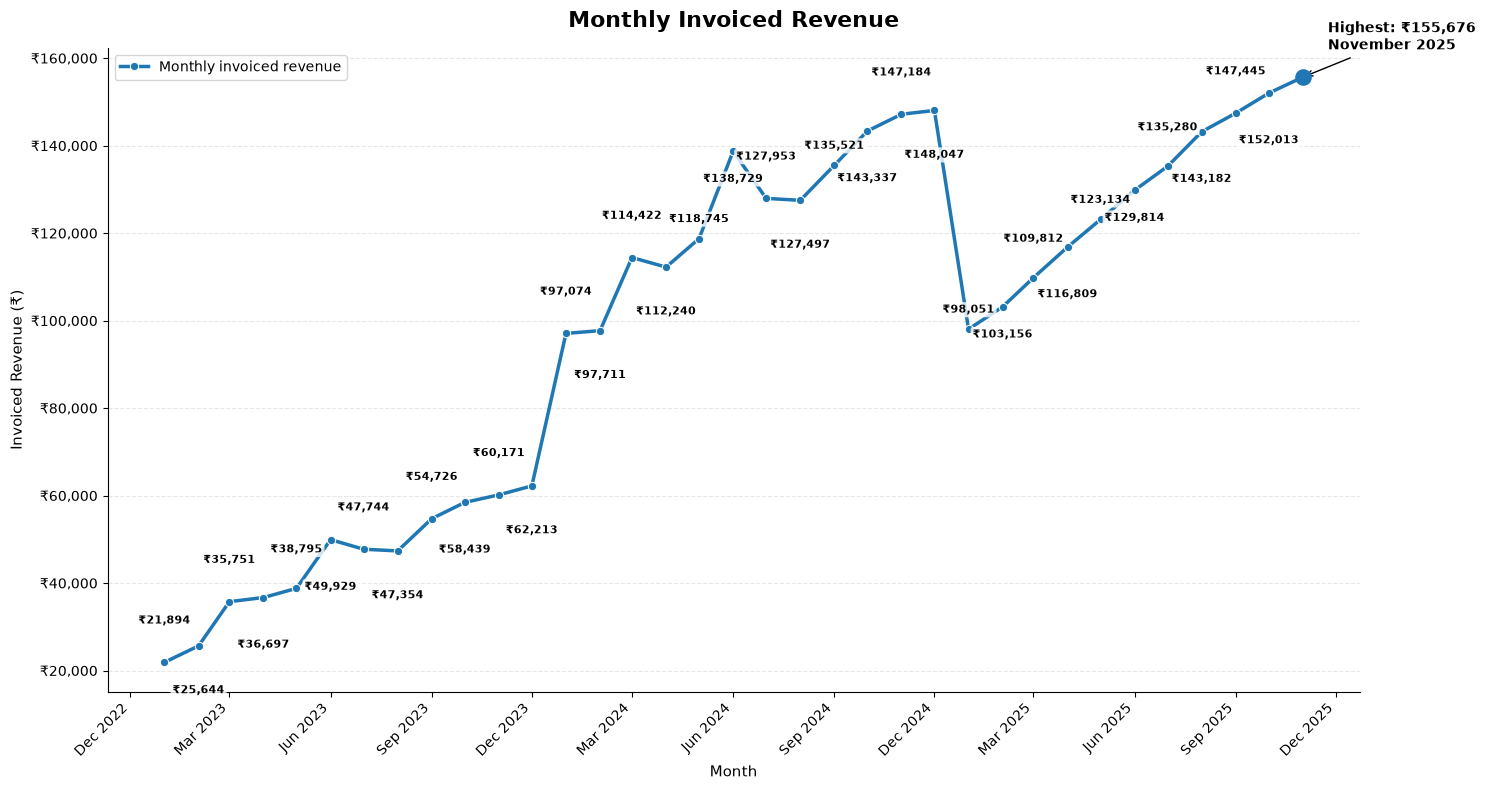

Highest monthly revenue: ₹155,676.00 (November 2025)


In [70]:
from matplotlib.ticker import FuncFormatter

# Find highest-revenue month
max_revenue_idx = monthly_revenue["invoiced_revenue"].idxmax()

max_revenue_month = monthly_revenue.loc[
    max_revenue_idx, "invoice_month"
]

max_revenue = monthly_revenue.loc[
    max_revenue_idx, "invoiced_revenue"
]

# ---------------------------------------------------------
# Create figure
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(15, 8))

# Plot monthly revenue
sns.lineplot(
    data=monthly_revenue,
    x="invoice_month",
    y="invoiced_revenue",
    marker="o",
    linewidth=2.5,
    markersize=6,
    label="Monthly invoiced revenue",
    ax=ax
)

# ---------------------------------------------------------
# Smart data-label positioning
# ---------------------------------------------------------

revenue_values = monthly_revenue["invoiced_revenue"].values

# Different vertical positions to reduce overlap
offset_levels = [14, -20, 28, -34]

for i, row in monthly_revenue.iterrows():

    # Highest point gets its own annotation
    if i == max_revenue_idx:
        continue

    offset = offset_levels[i % len(offset_levels)]

    # Detect nearby values
    if i > 0:
        previous_revenue = revenue_values[i - 1]

        if abs(row["invoiced_revenue"] - previous_revenue) < 5000:
            offset = 28 if offset > 0 else -32

    if i < len(revenue_values) - 1:
        next_revenue = revenue_values[i + 1]

        if abs(row["invoiced_revenue"] - next_revenue) < 5000:
            offset = 30 if offset > 0 else -34

    ax.annotate(
        f"₹{row['invoiced_revenue']:,.0f}",
        xy=(row["invoice_month"], row["invoiced_revenue"]),
        xytext=(0, offset),
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.18",
            facecolor="white",
            edgecolor="none",
            alpha=0.8
        )
    )

# ---------------------------------------------------------
# Highlight highest-revenue month
# ---------------------------------------------------------

ax.scatter(
    max_revenue_month,
    max_revenue,
    s=120,
    zorder=5
)

ax.annotate(
    f"Highest: ₹{max_revenue:,.0f}\n"
    f"{max_revenue_month:%B %Y}",
    xy=(max_revenue_month, max_revenue),
    xytext=(18, 20),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->")
)

# ---------------------------------------------------------
# Titles and labels
# ---------------------------------------------------------

ax.set_title(
    "Monthly Invoiced Revenue",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Month",
    fontsize=11
)

ax.set_ylabel(
    "Invoiced Revenue (₹)",
    fontsize=11
)

# ---------------------------------------------------------
# Format Y-axis as Indian-style currency display
# ---------------------------------------------------------

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"₹{x:,.0f}")
)

# ---------------------------------------------------------
# X-axis formatting
# ---------------------------------------------------------

ax.xaxis.set_major_locator(
    plt.matplotlib.dates.MonthLocator(interval=3)
)

ax.xaxis.set_major_formatter(
    plt.matplotlib.dates.DateFormatter("%b %Y")
)

plt.xticks(
    rotation=45,
    ha="right"
)

# ---------------------------------------------------------
# Grid
# ---------------------------------------------------------

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

sns.despine()

# Legend
ax.legend(
    loc="upper left",
    frameon=True
)

plt.tight_layout()

# ---------------------------------------------------------
# Save final portfolio version
# ---------------------------------------------------------

fig.savefig(
    "../outputs/figures/monthly_invoiced_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Highest monthly revenue: "
    f"₹{max_revenue:,.2f} "
    f"({max_revenue_month:%B %Y})"
)

**Interactive view:** Hover over the points to inspect monthly invoiced revenue.

In [105]:
import plotly.express as px

fig = px.line(
    monthly_revenue,
    x="invoice_month",
    y="invoiced_revenue",
    markers=True,
    title="Interactive Monthly Invoiced Revenue"
)

fig.update_traces(
    hovertemplate=(
        "<b>%{x|%B %Y}</b><br>"
        "Invoiced Revenue: ₹%{y:,.0f}"
        "<extra></extra>"
    )
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Invoiced Revenue (₹)",
    hovermode="x unified",
    template="plotly_white"
)

# Save the interactive figure
fig.write_html(
    "../outputs/figures/interactive_monthly_revenue.html",
    include_plotlyjs=True
)

fig.show()

**MoM reference check:** Recalculate and display the month-over-month revenue growth values for reference and to confirm the largest monthly increase and decline identified earlier.

In [72]:
# Calculate month-over-month revenue growth
monthly_revenue["mom_growth_pct"] = (
    monthly_revenue["invoiced_revenue"]
    .pct_change()
    * 100
)

monthly_revenue["mom_growth_pct"] = (
    monthly_revenue["mom_growth_pct"]
    .round(2)
)

# Display the results
display(
    monthly_revenue[
        [
            "invoice_month",
            "invoiced_revenue",
            "mom_growth_pct"
        ]
    ].head(15)
)

print("\nLargest monthly revenue increase:")

max_growth_idx = (
    monthly_revenue["mom_growth_pct"].idxmax()
)

print(
    f"{monthly_revenue.loc[max_growth_idx, 'invoice_month']:%B %Y}: "
    f"{monthly_revenue.loc[max_growth_idx, 'mom_growth_pct']:.2f}%"
)

print("\nLargest monthly revenue decline:")

min_growth_idx = (
    monthly_revenue["mom_growth_pct"].idxmin()
)

print(
    f"{monthly_revenue.loc[min_growth_idx, 'invoice_month']:%B %Y}: "
    f"{monthly_revenue.loc[min_growth_idx, 'mom_growth_pct']:.2f}%"
)

,invoice_month,invoiced_revenue,mom_growth_pct
0,2023-01-01,21894.0,NaN
1,2023-02-01,25644.0,17.13
2,2023-03-01,35751.0,39.41
3,2023-04-01,36697.0,2.65
4,2023-05-01,38795.0,5.72
5,2023-06-01,49929.0,28.70
6,2023-07-01,47744.0,-4.38
7,2023-08-01,47354.0,-0.82
8,2023-09-01,54726.0,15.57
9,2023-10-01,58439.0,6.78



Largest monthly revenue increase:
January 2024: 56.03%

Largest monthly revenue decline:
January 2025: -33.77%


### 8.5 Revenue by Subscription Plan

**Revenue summary by plan:** Aggregate invoice count, invoiced revenue, average invoice value, and revenue share across subscription plans and billing cycles.

In [73]:
plan_revenue = (
    invoice_plan
    .groupby(["plan_name", "billing_cycle"])
    .agg(
        invoices=("invoice_id", "nunique"),
        invoiced_revenue=("amount", "sum"),
        average_invoice=("amount", "mean")
    )
    .reset_index()
)

plan_revenue["revenue_share_pct"] = (
    plan_revenue["invoiced_revenue"]
    / plan_revenue["invoiced_revenue"].sum()
    * 100
).round(2)

plan_revenue["invoiced_revenue"] = (
    plan_revenue["invoiced_revenue"].round(2)
)

plan_revenue["average_invoice"] = (
    plan_revenue["average_invoice"].round(2)
)

plan_revenue = plan_revenue.sort_values(
    "invoiced_revenue",
    ascending=False
)

display(plan_revenue)

,plan_name,billing_cycle,invoices,invoiced_revenue,average_invoice,revenue_share_pct
3,Premium,monthly,9177,908523.0,99.0,26.24
5,Pro,monthly,18436,903364.0,49.0,26.09
1,Basic,monthly,38358,728802.0,19.0,21.05
2,Premium,annual,335,331650.0,990.0,9.58
4,Pro,annual,633,310170.0,490.0,8.96
0,Basic,annual,1472,279680.0,190.0,8.08


### 8.6 Revenue Contribution by Subscription Plan
Visualize the share of total invoiced revenue contributed by each subscription plan and billing cycle.

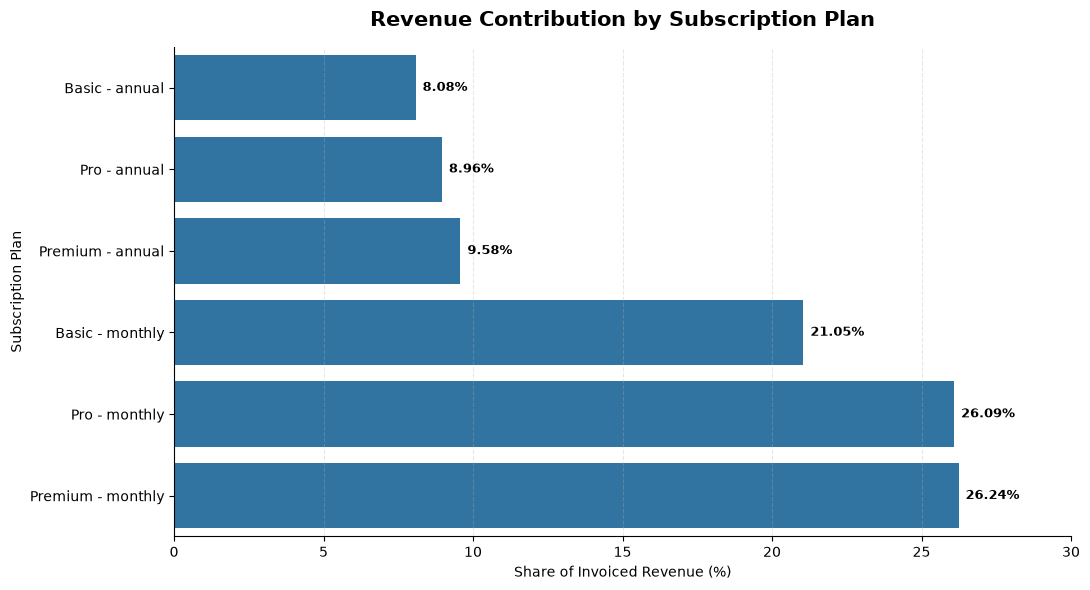

In [74]:
# Create a readable plan category
plan_revenue["plan_category"] = (
    plan_revenue["plan_name"]
    + " - "
    + plan_revenue["billing_cycle"]
)

# Sort for visual presentation
plot_data = plan_revenue.sort_values(
    "revenue_share_pct",
    ascending=True
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=plot_data,
    x="revenue_share_pct",
    y="plan_category",
    ax=ax
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=5,
        fontsize=9,
        fontweight="bold"
    )

ax.set_title(
    "Revenue Contribution by Subscription Plan",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Share of Invoiced Revenue (%)")
ax.set_ylabel("Subscription Plan")

ax.set_xlim(0, 30)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

sns.despine()

plt.tight_layout()

fig.savefig(
    "../outputs/figures/revenue_contribution_by_plan.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 8.7 Revenue per Customer
Calculate revenue per customer using both the full customer base and customers currently subscribed to paid plans.

In [75]:
# Total invoiced revenue
total_revenue = invoices["amount"].sum()

# Customers with a paid subscription plan
paid_customers = customer_master[
    customer_master["price"] > 0
]["customer_id"].nunique()

# All customers
total_customers = customer_master["customer_id"].nunique()

# Revenue per customer across entire customer base
revenue_per_customer = (
    total_revenue / total_customers
)

# Revenue per paying customer
revenue_per_paying_customer = (
    total_revenue / paid_customers
)

print(f"Total customers: {total_customers:,}")
print(f"Paid-plan customers: {paid_customers:,}")
print(f"Total invoiced revenue: ₹{total_revenue:,.2f}")
print(
    f"Revenue per customer: "
    f"₹{revenue_per_customer:,.2f}"
)
print(
    f"Revenue per paying customer: "
    f"₹{revenue_per_paying_customer:,.2f}"
)

Total customers: 25,000
Paid-plan customers: 10,813
Total invoiced revenue: ₹3,462,189.00
Revenue per customer: ₹138.49
Revenue per paying customer: ₹320.19


### 8.8 Paying Customer Definition

In [76]:
# Connect invoices to customers
invoice_customers = invoices.merge(
    subscriptions[
        ["subscription_id", "customer_id"]
    ],
    on="subscription_id",
    how="left",
    validate="many_to_one"
)

# Identify customers with at least one positive-value invoice
paying_customer_ids = (
    invoice_customers.loc[
        invoice_customers["amount"] > 0,
        "customer_id"
    ]
    .unique()
)

actual_paying_customers = len(paying_customer_ids)

# Recalculate cumulative revenue per actual paying customer
revenue_per_actual_paying_customer = (
    total_revenue / actual_paying_customers
)

print(f"All customers: {total_customers:,}")
print(
    f"Customers with at least one paid invoice: "
    f"{actual_paying_customers:,}"
)
print(
    f"Revenue per actual paying customer: "
    f"₹{revenue_per_actual_paying_customer:,.2f}"
)

All customers: 25,000
Customers with at least one paid invoice: 8,027
Revenue per actual paying customer: ₹431.32


**Paying customer definition check:** Compare the current paid-plan definition with a transaction-based definition using customers with at least one positive-value invoice.

In [77]:
paying_customer_comparison = pd.DataFrame({
    "Definition": [
        "Customer currently on paid plan",
        "Customer with ≥1 positive-value invoice"
    ],
    "Customer Count": [
        paid_customers,
        actual_paying_customers
    ]
})

display(paying_customer_comparison)

,Definition,Customer Count
0,Customer currently on paid plan,10813
1,Customer with ≥1 positive-value invoice,8027


## 9. Payment Performance Analysis

Analyze payment success and failure rates, payment performance by subscription plan, and whether payment outcomes are statistically associated with subscription plans.

### 9.1 Payment Success and Failure

In [78]:
# Total payment transactions and amount
total_payment_transactions = len(payments)
total_payment_amount = payments["amount"].sum()

payment_performance = (
    payments
    .groupby("status")
    .agg(
        transactions=("payment_id", "count"),
        total_amount=("amount", "sum"),
        average_amount=("amount", "mean")
    )
    .reset_index()
)

# Transaction share
payment_performance["transaction_share_pct"] = (
    payment_performance["transactions"]
    / total_payment_transactions
    * 100
)

# Amount share
payment_performance["amount_share_pct"] = (
    payment_performance["total_amount"]
    / total_payment_amount
    * 100
)

# Round numerical values
payment_performance["total_amount"] = (
    payment_performance["total_amount"].round(2)
)

payment_performance["average_amount"] = (
    payment_performance["average_amount"].round(2)
)

payment_performance["transaction_share_pct"] = (
    payment_performance["transaction_share_pct"].round(2)
)

payment_performance["amount_share_pct"] = (
    payment_performance["amount_share_pct"].round(2)
)

display(payment_performance)

,status,transactions,total_amount,average_amount,transaction_share_pct,amount_share_pct
0,failed,4797,240760.0,50.19,7.01,6.95
1,successful,63614,3221429.0,50.64,92.99,93.05


### 9.2 Payment Performance by Transaction and Amount Share
Visualize successful and failed payments by comparing their shares of total transactions and total payment amount.

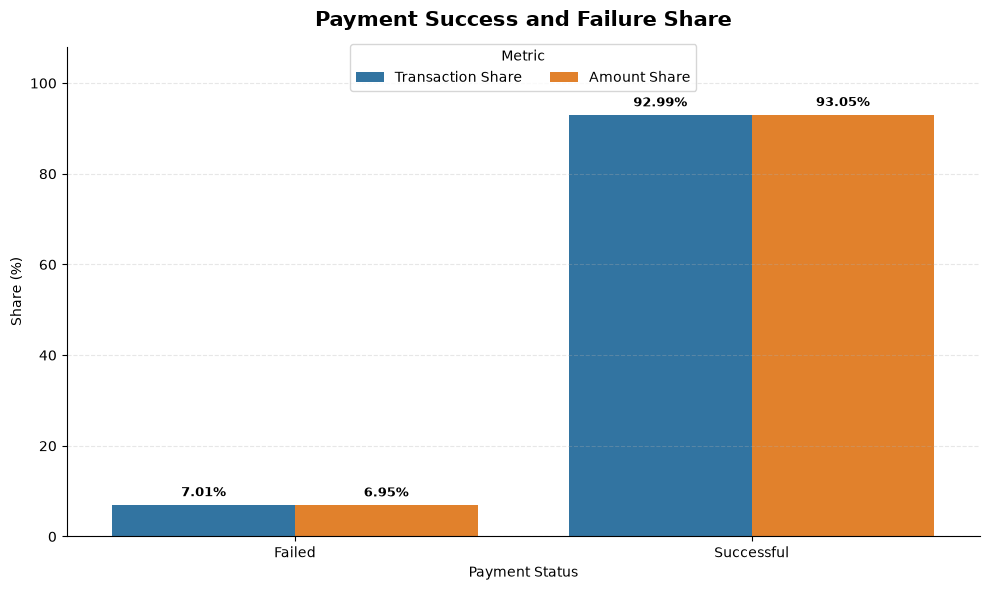

In [79]:
# Create data for visualization
payment_plot = payment_performance.copy()

payment_plot["status"] = (
    payment_plot["status"]
    .str.title()
)

# Reshape for grouped comparison
payment_share_plot = payment_plot[
    [
        "status",
        "transaction_share_pct",
        "amount_share_pct"
    ]
].melt(
    id_vars="status",
    var_name="metric",
    value_name="percentage"
)

# Cleaner metric names
payment_share_plot["metric"] = (
    payment_share_plot["metric"]
    .replace({
        "transaction_share_pct": "Transaction Share",
        "amount_share_pct": "Amount Share"
    })
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=payment_share_plot,
    x="status",
    y="percentage",
    hue="metric",
    ax=ax
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=4,
        fontsize=9,
        fontweight="bold"
    )

ax.set_title(
    "Payment Success and Failure Share",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Payment Status")
ax.set_ylabel("Share (%)")

ax.set_ylim(0, 108)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

sns.despine()

ax.legend(
    title="Metric",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=True
)

plt.tight_layout()

fig.savefig(
    "../outputs/figures/payment_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 9.3 Payment Failure by Subscription Plan
Join payment records with subscription-plan information and prepare the data for plan-level payment failure analysis.

In [80]:
payment_plan = payments.merge(
    subscriptions[
        ["subscription_id", "plan_id"]
    ],
    on="subscription_id",
    how="left",
    validate="many_to_one"
)

payment_plan = payment_plan.merge(
    subscription_plans[
        ["plan_id", "plan_name", "billing_cycle"]
    ],
    on="plan_id",
    how="left",
    validate="many_to_one"
)

print("Payment records:", len(payment_plan))

print(
    "Original payment records:",
    len(payments)
)

display(payment_plan.head())

Payment records: 68411
Original payment records: 68411


,payment_id,subscription_id,payment_date,amount,status,failure_reason,plan_id,plan_name,billing_cycle
0,1,1,2023-05-11,190.0,successful,NaN,5,Basic,annual
1,2,1,2024-05-11,190.0,successful,NaN,5,Basic,annual
2,3,9,2023-10-13,490.0,successful,NaN,6,Pro,annual
3,4,9,2024-10-13,490.0,successful,NaN,6,Pro,annual
4,5,10,2023-01-31,99.0,successful,NaN,4,Premium,monthly


**Plan-level failure summary:** Calculate transaction counts, failed transactions, and payment failure rates for each subscription plan and billing cycle.

In [81]:
plan_payment_performance = (
    payment_plan
    .groupby(["plan_name", "billing_cycle"])
    .agg(
        total_transactions=("payment_id", "count"),
        failed_transactions=(
            "status",
            lambda x: (x == "failed").sum()
        ),
        successful_transactions=(
            "status",
            lambda x: (x == "successful").sum()
        ),
        total_payment_amount=("amount", "sum"),
        failed_payment_amount=(
            "amount",
            lambda x: x[
                payment_plan.loc[x.index, "status"] == "failed"
            ].sum()
        )
    )
    .reset_index()
)

# Calculate failure rate
plan_payment_performance["failure_rate_pct"] = (
    plan_payment_performance["failed_transactions"]
    / plan_payment_performance["total_transactions"]
    * 100
)

# Calculate success rate
plan_payment_performance["success_rate_pct"] = (
    plan_payment_performance["successful_transactions"]
    / plan_payment_performance["total_transactions"]
    * 100
)

# Calculate failed amount share
plan_payment_performance["failed_amount_share_pct"] = (
    plan_payment_performance["failed_payment_amount"]
    / plan_payment_performance["total_payment_amount"]
    * 100
)

# Round percentages and monetary values
percentage_columns = [
    "failure_rate_pct",
    "success_rate_pct",
    "failed_amount_share_pct"
]

plan_payment_performance[percentage_columns] = (
    plan_payment_performance[percentage_columns].round(2)
)

plan_payment_performance[
    ["total_payment_amount", "failed_payment_amount"]
] = (
    plan_payment_performance[
        ["total_payment_amount", "failed_payment_amount"]
    ].round(2)
)

# Sort by failure rate
plan_payment_performance = (
    plan_payment_performance
    .sort_values("failure_rate_pct", ascending=False)
)

display(plan_payment_performance)

,plan_name,billing_cycle,total_transactions,failed_transactions,successful_transactions,total_payment_amount,failed_payment_amount,failure_rate_pct,success_rate_pct,failed_amount_share_pct
0,Basic,annual,1472,115,1357,279680.0,21850.0,7.81,92.19,7.81
5,Pro,monthly,18436,1299,17137,903364.0,63651.0,7.05,92.95,7.05
1,Basic,monthly,38358,2680,35678,728802.0,50920.0,6.99,93.01,6.99
3,Premium,monthly,9177,641,8536,908523.0,63459.0,6.98,93.02,6.98
4,Pro,annual,633,41,592,310170.0,20090.0,6.48,93.52,6.48
2,Premium,annual,335,21,314,331650.0,20790.0,6.27,93.73,6.27


Visualize payment failure rates across subscription plans and billing cycles.

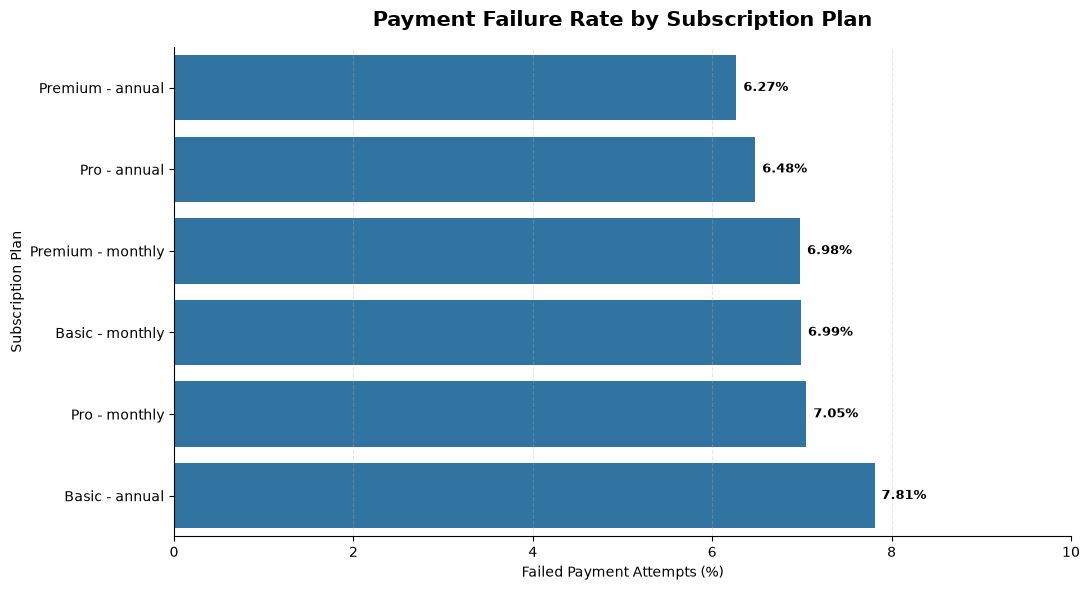

In [82]:
# Create readable plan category
plan_payment_performance["plan_category"] = (
    plan_payment_performance["plan_name"]
    + " - "
    + plan_payment_performance["billing_cycle"]
)

# Sort from lowest to highest failure rate
failure_plot = plan_payment_performance.sort_values(
    "failure_rate_pct",
    ascending=True
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=failure_plot,
    x="failure_rate_pct",
    y="plan_category",
    ax=ax
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=5,
        fontsize=9,
        fontweight="bold"
    )

ax.set_title(
    "Payment Failure Rate by Subscription Plan",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Failed Payment Attempts (%)")
ax.set_ylabel("Subscription Plan")

ax.set_xlim(0, 10)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

sns.despine()

plt.tight_layout()

fig.savefig(
    "../outputs/figures/payment_failure_rate_by_plan.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 9.4 Statistical Test: Subscription Plan vs. Payment Outcome

Use a chi-square test of independence to assess whether payment outcome is statistically associated with subscription plan and billing cycle.

In [83]:
from scipy.stats import chi2_contingency

# Create contingency table
plan_payment_table = pd.crosstab(
    payment_plan["plan_name"] + " - " + payment_plan["billing_cycle"],
    payment_plan["status"]
)

plan_payment_table.columns = ["Failed", "Successful"]

display(plan_payment_table)

# Chi-square test
chi2_payment, p_payment, dof_payment, expected_payment = (
    chi2_contingency(plan_payment_table)
)

print(f"Chi-square statistic: {chi2_payment:.4f}")
print(f"P-value: {p_payment:.6g}")
print(f"Degrees of freedom: {dof_payment}")
print(
    f"Minimum expected frequency: "
    f"{expected_payment.min():.2f}"
)

,Failed,Successful
row_0,,
Basic - annual,115,1357
Basic - monthly,2680,35678
Premium - annual,21,314
Premium - monthly,641,8536
Pro - annual,41,592
Pro - monthly,1299,17137


Chi-square statistic: 2.0887
P-value: 0.836742
Degrees of freedom: 5
Minimum expected frequency: 23.49


**Effect size:** Calculate Cramér's V to quantify the strength of the association between subscription plan and payment outcome.

In [84]:
# Calculate Cramér's V for plan category vs payment outcome

n_payment = plan_payment_table.to_numpy().sum()
r_payment, c_payment = plan_payment_table.shape

cramers_v_payment = np.sqrt(
    chi2_payment
    / (
        n_payment
        * min(r_payment - 1, c_payment - 1)
    )
)

print(f"Total payment transactions: {n_payment:,}")
print(f"Cramér's V: {cramers_v_payment:.4f}")

Total payment transactions: 68,411
Cramér's V: 0.0055


### 9.5 Consolidated Statistical Summary

Combine the statistical tests from the churn and payment analyses into a single summary table for comparison and interpretation.

In [85]:
payment_statistical_summary = pd.DataFrame({
    "Variable": [
        "Acquisition Channel vs Churn",
        "Industry vs Churn",
        "Subscription Plan vs Churn",
        "Subscription Plan vs Payment Outcome"
    ],
    "Chi-square": [
        chi2,
        chi2_ind,
        chi2_plan,
        chi2_payment
    ],
    "P-value": [
        p_value,
        p_ind,
        p_plan,
        p_payment
    ],
    "Degrees of Freedom": [
        dof,
        dof_ind,
        dof_plan,
        dof_payment
    ],
    "Cramers_V": [
        np.sqrt(chi2 / 25000),
        np.sqrt(chi2_ind / 25000),
        cramers_v,
        cramers_v_payment
    ]
})

payment_statistical_summary["Significant_5pct"] = (
    payment_statistical_summary["P-value"] < 0.05
)

display(
    payment_statistical_summary.round(4)
)

,Variable,Chi-square,P-value,Degrees of Freedom,Cramers_V,Significant_5pct
0,Acquisition Channel vs Churn,0.0754,0.9630,2,0.0017,False
1,Industry vs Churn,7.5349,0.0567,3,0.0174,False
2,Subscription Plan vs Churn,2932.4561,0.0000,6,0.3425,True
3,Subscription Plan vs Payment Outcome,2.0887,0.8367,5,0.0055,False


## 10. Plan Change Analysis

Analyze recorded subscription plan changes, customer participation in plan changes, monthly conversion activity, and the time taken to move from signup to a new plan.

### 10.1 Plan Transition Overview

In [86]:
# Add details for the old plan
plan_change_analysis = plan_changes.merge(
    subscription_plans[
        ["plan_id", "plan_name", "billing_cycle", "price"]
    ].rename(
        columns={
            "plan_id": "old_plan_id",
            "plan_name": "old_plan_name",
            "billing_cycle": "old_billing_cycle",
            "price": "old_price"
        }
    ),
    on="old_plan_id",
    how="left",
    validate="many_to_one"
)

# Add details for the new plan
plan_change_analysis = plan_change_analysis.merge(
    subscription_plans[
        ["plan_id", "plan_name", "billing_cycle", "price"]
    ].rename(
        columns={
            "plan_id": "new_plan_id",
            "plan_name": "new_plan_name",
            "billing_cycle": "new_billing_cycle",
            "price": "new_price"
        }
    ),
    on="new_plan_id",
    how="left",
    validate="many_to_one"
)

print("Plan change records:", len(plan_change_analysis))
print(
    "Unique subscriptions with plan changes:",
    plan_change_analysis["subscription_id"].nunique()
)

display(plan_change_analysis.head(10))

Plan change records: 787
Unique subscriptions with plan changes: 787


,change_id,subscription_id,old_plan_id,new_plan_id,change_date,old_plan_name,old_billing_cycle,old_price,new_plan_name,new_billing_cycle,new_price
0,1,23,1,2,2023-08-27,Free,monthly,0.0,Basic,monthly,19.0
1,2,30,1,2,2023-09-25,Free,monthly,0.0,Basic,monthly,19.0
2,3,42,1,2,2024-06-17,Free,monthly,0.0,Basic,monthly,19.0
3,4,82,1,2,2024-09-05,Free,monthly,0.0,Basic,monthly,19.0
4,5,97,1,2,2024-09-08,Free,monthly,0.0,Basic,monthly,19.0
5,6,107,1,2,2025-04-21,Free,monthly,0.0,Basic,monthly,19.0
6,7,145,1,2,2025-12-04,Free,monthly,0.0,Basic,monthly,19.0
7,8,149,1,2,2024-09-13,Free,monthly,0.0,Basic,monthly,19.0
8,9,175,1,2,2025-07-01,Free,monthly,0.0,Basic,monthly,19.0
9,10,179,1,2,2025-12-15,Free,monthly,0.0,Basic,monthly,19.0


In [87]:
plan_transitions = (
    plan_change_analysis
    .groupby(
        [
            "old_plan_name",
            "old_billing_cycle",
            "new_plan_name",
            "new_billing_cycle"
        ]
    )
    .agg(
        plan_changes=("change_id", "nunique")
    )
    .reset_index()
    .sort_values(
        "plan_changes",
        ascending=False
    )
)

display(plan_transitions)

,old_plan_name,old_billing_cycle,new_plan_name,new_billing_cycle,plan_changes
0,Free,monthly,Basic,monthly,787


### 10.2 Plan Change Customer Outcomes

Combine plan-change records with subscription lifecycle information to examine customer outcomes and the timing of recorded plan changes.

In [88]:
# Bring subscription lifecycle information into plan changes
plan_change_outcomes = plan_changes.merge(
    subscriptions[
        [
            "subscription_id",
            "customer_id",
            "start_date",
            "end_date",
            "status"
        ]
    ],
    on="subscription_id",
    how="left",
    validate="one_to_one"
)

# Calculate time from subscription start to plan change
plan_change_outcomes["days_to_change"] = (
    plan_change_outcomes["change_date"]
    - plan_change_outcomes["start_date"]
).dt.days

# For customers who churned, calculate time from plan change to churn
plan_change_outcomes["days_after_change_to_churn"] = np.where(
    plan_change_outcomes["status"] == "churned",
    (
        plan_change_outcomes["end_date"]
        - plan_change_outcomes["change_date"]
    ).dt.days,
    np.nan
)

# Basic outcome summary
outcome_summary = (
    plan_change_outcomes
    .groupby("status")
    .agg(
        customers=("customer_id", "nunique"),
        average_days_to_change=("days_to_change", "mean"),
        median_days_to_change=("days_to_change", "median")
    )
    .reset_index()
)

outcome_summary[
    ["average_days_to_change", "median_days_to_change"]
] = (
    outcome_summary[
        ["average_days_to_change", "median_days_to_change"]
    ].round(2)
)

display(outcome_summary)

print("\nPlan-change customer count:", 
      plan_change_outcomes["customer_id"].nunique())

print(
    "Average days from signup to plan change:",
    f"{plan_change_outcomes['days_to_change'].mean():.2f}"
)

print(
    "Median days from signup to plan change:",
    f"{plan_change_outcomes['days_to_change'].median():.0f}"
)

,status,customers,average_days_to_change,median_days_to_change
0,active,787,234.41,183.0



Plan-change customer count: 787
Average days from signup to plan change: 234.41
Median days from signup to plan change: 183


### 10.3 Customer Plan-Change Rate

Measure the proportion of customers with a recorded subscription plan change relative to the full customer base.

In [89]:
total_customers = customer_master["customer_id"].nunique()

plan_change_customers = (
    plan_change_outcomes["customer_id"].nunique()
)

plan_change_rate = (
    plan_change_customers
    / total_customers
    * 100
)

print(f"Total customers: {total_customers:,}")
print(
    f"Customers with a recorded plan change: "
    f"{plan_change_customers:,}"
)
print(
    f"Customer plan-change rate: "
    f"{plan_change_rate:.2f}%"
)

Total customers: 25,000
Customers with a recorded plan change: 787
Customer plan-change rate: 3.15%


### 10.4 Monthly Plan Changes

Examine how recorded plan changes vary over time and identify periods with higher conversion activity.

In [90]:
# Group plan changes by month
monthly_plan_changes = (
    plan_changes
    .assign(
        change_month=plan_changes["change_date"].dt.to_period("M")
    )
    .groupby("change_month")
    .agg(
        plan_changes=("change_id", "nunique"),
        customers=("subscription_id", "nunique")
    )
    .reset_index()
)

# Convert Period to timestamp
monthly_plan_changes["change_month"] = (
    monthly_plan_changes["change_month"].dt.to_timestamp()
)

display(monthly_plan_changes.head(10))
display(monthly_plan_changes.tail(10))

print(
    "Total recorded plan changes:",
    monthly_plan_changes["plan_changes"].sum()
)

,change_month,plan_changes,customers
0,2023-02-01,1,1
1,2023-03-01,3,3
2,2023-04-01,2,2
3,2023-05-01,4,4
4,2023-06-01,5,5
5,2023-07-01,5,5
6,2023-08-01,9,9
7,2023-09-01,12,12
8,2023-10-01,13,13
9,2023-11-01,15,15


,change_month,plan_changes,customers
25,2025-03-01,33,33
26,2025-04-01,31,31
27,2025-05-01,37,37
28,2025-06-01,33,33
29,2025-07-01,33,33
30,2025-08-01,38,38
31,2025-09-01,41,41
32,2025-10-01,42,42
33,2025-11-01,47,47
34,2025-12-01,50,50


Total recorded plan changes: 787


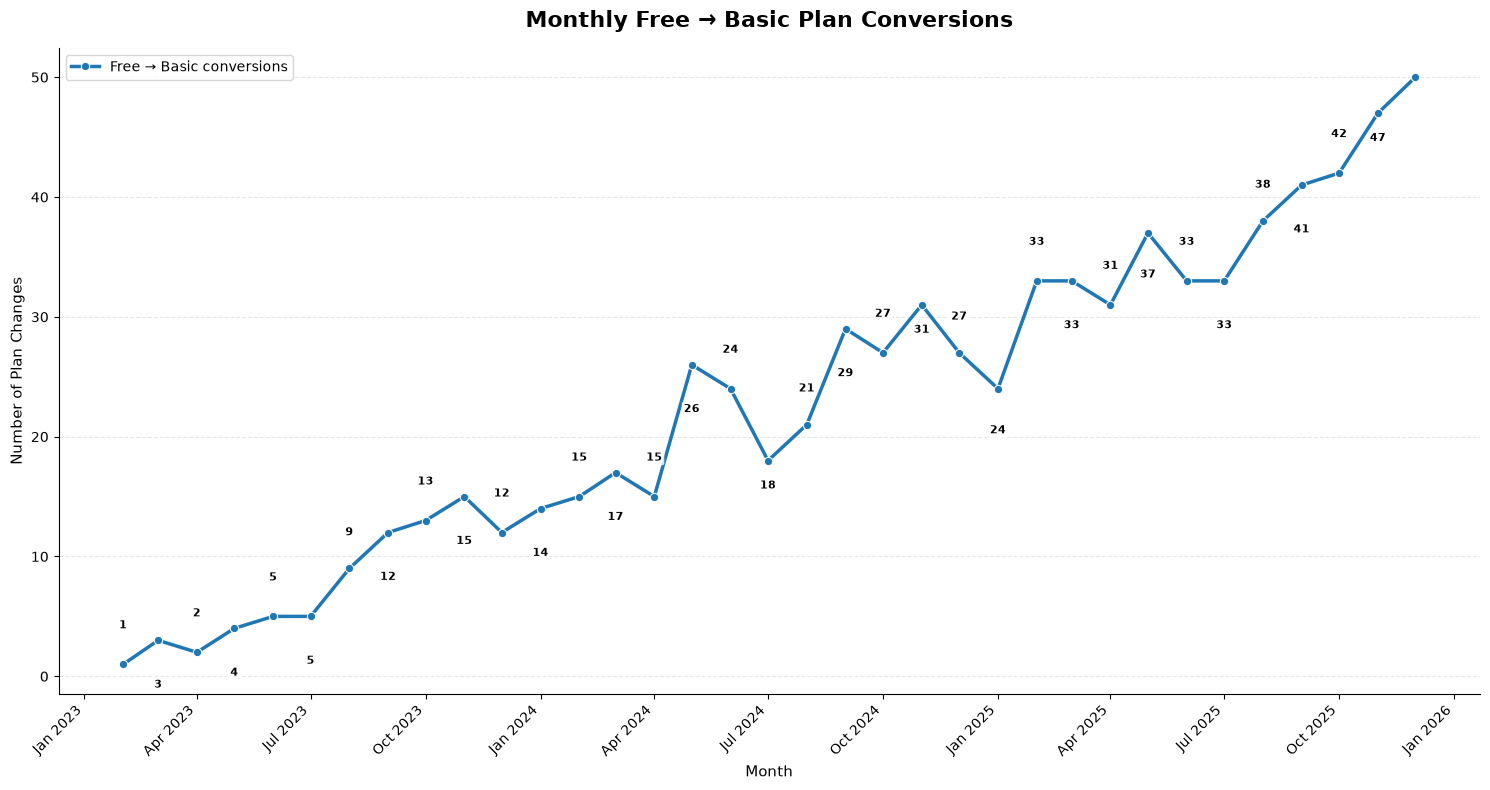

Highest monthly conversions: 50 (December 2025)


In [91]:
# Find the month with the highest number of plan changes
max_change_idx = monthly_plan_changes["plan_changes"].idxmax()

max_change_month = monthly_plan_changes.loc[
    max_change_idx, "change_month"
]

max_changes = monthly_plan_changes.loc[
    max_change_idx, "plan_changes"
]

fig, ax = plt.subplots(figsize=(15, 8))

# Plot monthly plan changes
sns.lineplot(
    data=monthly_plan_changes,
    x="change_month",
    y="plan_changes",
    marker="o",
    linewidth=2.5,
    markersize=6,
    label="Free → Basic conversions",
    ax=ax
)

# Smart data-label positioning
for i, row in monthly_plan_changes.iterrows():

    offset_levels = [14, -18, 26, -30]
    offset = offset_levels[i % len(offset_levels)]

    # Increase separation when neighboring values are close
    if i > 0:
        previous_value = monthly_plan_changes.loc[
            i - 1, "plan_changes"
        ]

        if abs(row["plan_changes"] - previous_value) <= 2:
            offset = 28 if offset > 0 else -32

    if i < len(monthly_plan_changes) - 1:
        next_value = monthly_plan_changes.loc[
            i + 1, "plan_changes"
        ]

        if abs(row["plan_changes"] - next_value) <= 2:
            offset = 28 if offset > 0 else -32

    # Highlighted maximum gets its own callout
    if i == max_change_idx:
        continue

    ax.annotate(
        f"{row['plan_changes']}",
        xy=(row["change_month"], row["plan_changes"]),
        xytext=(0, offset),
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.18",
            facecolor="white",
            edgecolor="none",
            alpha=0.8
        )
    )

# Titles
ax.set_title(
    "Monthly Free → Basic Plan Conversions",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Month",
    fontsize=11
)

ax.set_ylabel(
    "Number of Plan Changes",
    fontsize=11
)

# X-axis formatting
ax.xaxis.set_major_locator(
    plt.matplotlib.dates.MonthLocator(interval=3)
)

ax.xaxis.set_major_formatter(
    plt.matplotlib.dates.DateFormatter("%b %Y")
)

plt.xticks(
    rotation=45,
    ha="right"
)

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

sns.despine()

ax.legend(
    loc="upper left",
    frameon=True
)

plt.tight_layout()

fig.savefig(
    "../outputs/figures/monthly_free_to_basic_conversions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Highest monthly conversions: "
    f"{max_changes} ({max_change_month:%B %Y})"
)

### 10.5 Time to Free → Basic Conversion

Analyze the time between customer signup and the recorded Free → Basic plan change using summary statistics and a distribution plot.

In [92]:
# Summary of time from signup to Free → Basic conversion
conversion_timing = (
    plan_change_outcomes["days_to_change"]
    .describe()
    .round(2)
)

display(conversion_timing)

# Convert days to approximate months for easier interpretation
plan_change_outcomes["months_to_change"] = (
    plan_change_outcomes["days_to_change"] / 30.44
)

print(
    "Average time to plan change:",
    f"{plan_change_outcomes['months_to_change'].mean():.2f} months"
)

print(
    "Median time to plan change:",
    f"{plan_change_outcomes['months_to_change'].median():.2f} months"
)

count     787.00
mean      234.41
std       186.18
min        28.00
25%        92.00
50%       183.00
75%       306.00
max      1034.00
Name: days_to_change, dtype: float64

Average time to plan change: 7.70 months
Median time to plan change: 6.01 months


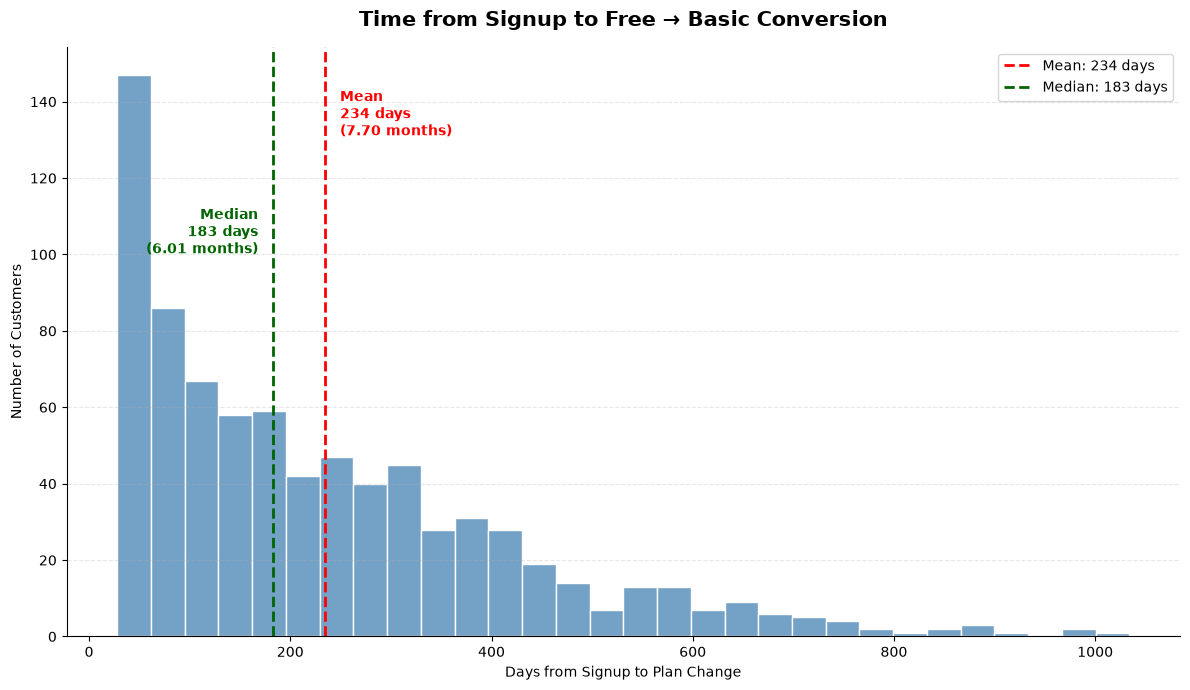

In [93]:
# Calculate mean and median
mean_days = plan_change_outcomes["days_to_change"].mean()
median_days = plan_change_outcomes["days_to_change"].median()

fig, ax = plt.subplots(figsize=(12, 7))

# Histogram
sns.histplot(
    data=plan_change_outcomes,
    x="days_to_change",
    bins=30,
    color="steelblue",
    edgecolor="white",
    ax=ax
)

# Mean line
ax.axvline(
    mean_days,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_days:.0f} days"
)

# Median line
ax.axvline(
    median_days,
    color="darkgreen",
    linestyle="--",
    linewidth=2,
    label=f"Median: {median_days:.0f} days"
)

# Labels for mean and median
ymax = ax.get_ylim()[1]

ax.text(
    mean_days + 15,
    ymax * 0.85,
    f"Mean\n{mean_days:.0f} days\n({mean_days / 30.44:.2f} months)",
    color="red",
    fontsize=10,
    fontweight="bold"
)

ax.text(
    median_days - 15,
    ymax * 0.65,
    f"Median\n{median_days:.0f} days\n({median_days / 30.44:.2f} months)",
    color="darkgreen",
    fontsize=10,
    fontweight="bold",
    ha="right"
)

# Titles
ax.set_title(
    "Time from Signup to Free → Basic Conversion",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Days from Signup to Plan Change"
)

ax.set_ylabel(
    "Number of Customers"
)

ax.legend()

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

sns.despine()

plt.tight_layout()

fig.savefig(
    "../outputs/figures/time_to_free_to_basic_conversion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 11. Customer Revenue & Retention

Analyze customer-level revenue alongside observed subscription tenure to understand monetization patterns across customer lifecycle stages and subscription plans.

### 11.1 Customer-Level Revenue and Tenure

In [94]:
# Aggregate invoiced revenue to the customer level
customer_revenue = (
    invoice_customers
    .groupby("customer_id")
    .agg(
        total_invoiced_revenue=("amount", "sum"),
        invoice_count=("invoice_id", "nunique")
    )
    .reset_index()
)

# Merge revenue with customer-level tenure
customer_revenue_analysis = customer_master[
    [
        "customer_id",
        "status",
        "tenure_months",
        "plan_name",
        "billing_cycle"
    ]
].merge(
    customer_revenue,
    on="customer_id",
    how="left",
    validate="one_to_one"
)

# Customers without invoices receive zero revenue
customer_revenue_analysis["total_invoiced_revenue"] = (
    customer_revenue_analysis["total_invoiced_revenue"]
    .fillna(0)
)

customer_revenue_analysis["invoice_count"] = (
    customer_revenue_analysis["invoice_count"]
    .fillna(0)
    .astype(int)
)

# Validation
print(
    "Customer records:",
    len(customer_revenue_analysis)
)

print(
    "Unique customers:",
    customer_revenue_analysis["customer_id"].nunique()
)

print(
    "Total customer-level revenue:",
    f"₹{customer_revenue_analysis['total_invoiced_revenue'].sum():,.2f}"
)

print(
    "Original invoice revenue:",
    f"₹{invoices['amount'].sum():,.2f}"
)

display(customer_revenue_analysis.head(10))

Customer records: 25000
Unique customers: 25000
Total customer-level revenue: ₹3,462,189.00
Original invoice revenue: ₹3,462,189.00


,customer_id,status,tenure_months,plan_name,billing_cycle,total_invoiced_revenue,invoice_count
0,1,active,31,Basic,annual,380.0,2
1,2,churned,7,Free,monthly,0.0,0
2,3,active,33,Free,monthly,0.0,0
3,4,churned,5,Free,monthly,0.0,0
4,5,churned,6,Free,monthly,0.0,0
5,6,churned,9,Free,monthly,0.0,0
6,7,churned,16,Free,monthly,0.0,0
7,8,churned,15,Free,monthly,0.0,0
8,9,active,26,Pro,annual,980.0,2
9,10,churned,13,Premium,monthly,1386.0,14


### 11.2 Tenure and Cumulative Revenue Association

Measure the association between observed subscription tenure and cumulative invoiced revenue using Spearman rank correlation.

In [95]:
from scipy.stats import spearmanr

# Spearman correlation across all customers
correlation, p_value_revenue = spearmanr(
    customer_revenue_analysis["tenure_months"],
    customer_revenue_analysis["total_invoiced_revenue"]
)

print(
    f"Spearman correlation: {correlation:.4f}"
)

print(
    f"P-value: {p_value_revenue:.6g}"
)

print(
    f"Customers analyzed: "
    f"{len(customer_revenue_analysis):,}"
)

Spearman correlation: 0.3491
P-value: 0
Customers analyzed: 25,000


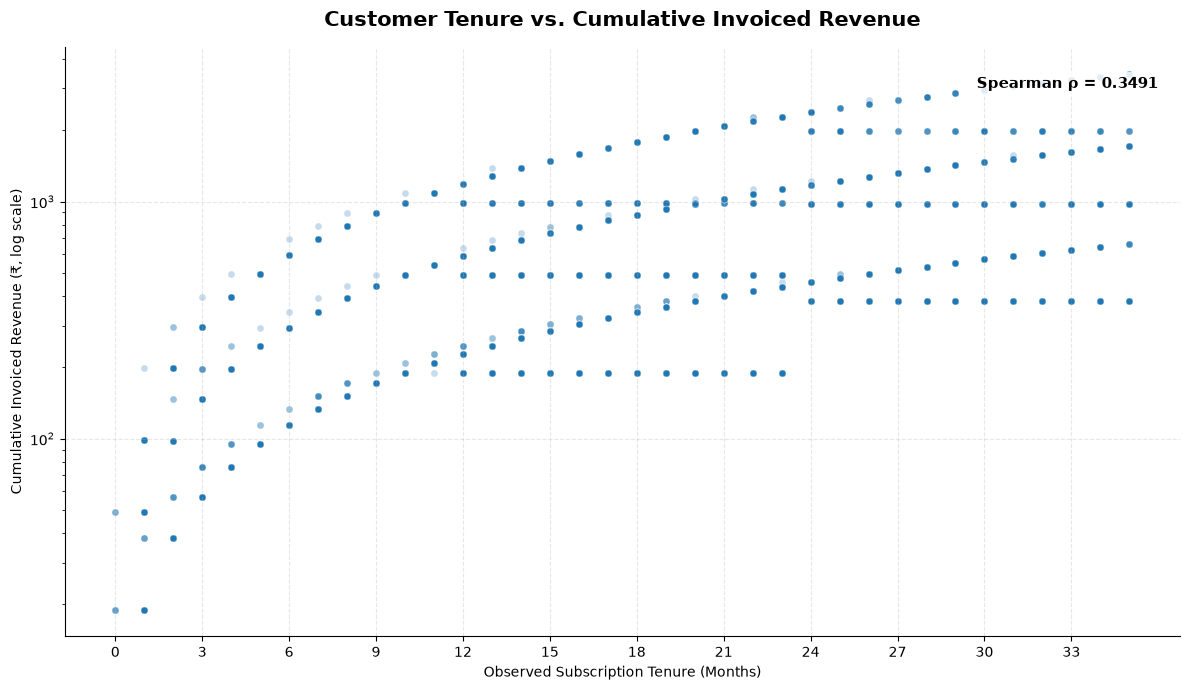

In [96]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(
    data=customer_revenue_analysis,
    x="tenure_months",
    y="total_invoiced_revenue",
    alpha=0.25,
    s=25,
    ax=ax
)

# Log scale helps display the wide revenue range
ax.set_yscale("log")

# Add correlation annotation
ax.text(
    0.98,
    0.95,
    f"Spearman ρ = {correlation:.4f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="none",
        alpha=0.85
    )
)

ax.set_title(
    "Customer Tenure vs. Cumulative Invoiced Revenue",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Observed Subscription Tenure (Months)")
ax.set_ylabel("Cumulative Invoiced Revenue (₹, log scale)")

ax.set_xticks(range(0, 36, 3))

ax.grid(
    axis="both",
    linestyle="--",
    alpha=0.3
)

sns.despine()

plt.tight_layout()

fig.savefig(
    "../outputs/figures/tenure_vs_cumulative_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 11.3 Customer Monetization by Tenure

Group customers into observed subscription-tenure bands and compare cumulative revenue and paying-customer rates across lifecycle stages.

In [97]:
# Create customer tenure bands
customer_revenue_analysis["tenure_band"] = pd.cut(
    customer_revenue_analysis["tenure_months"],
    bins=[-1, 3, 6, 12, 24, np.inf],
    labels=[
        "0–3 months",
        "4–6 months",
        "7–12 months",
        "13–24 months",
        "25+ months"
    ]
)

# Summarize revenue by tenure band
tenure_revenue = (
    customer_revenue_analysis
    .groupby("tenure_band", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        median_revenue=("total_invoiced_revenue", "median"),
        average_revenue=("total_invoiced_revenue", "mean")
    )
    .reset_index()
)

tenure_revenue["median_revenue"] = (
    tenure_revenue["median_revenue"].round(2)
)

tenure_revenue["average_revenue"] = (
    tenure_revenue["average_revenue"].round(2)
)

display(tenure_revenue)

,tenure_band,customers,median_revenue,average_revenue
0,0–3 months,6780,0.0,13.56
1,4–6 months,4504,0.0,44.33
2,7–12 months,6460,0.0,92.25
3,13–24 months,5445,0.0,271.77
4,25+ months,1811,380.0,604.53


In [98]:
# Identify customers who generated at least one positive-value invoice
customer_revenue_analysis["is_paying_customer"] = (
    customer_revenue_analysis["total_invoiced_revenue"] > 0
)

# Summarize customer monetization by tenure band
tenure_monetization = (
    customer_revenue_analysis
    .groupby("tenure_band", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        paying_customers=("is_paying_customer", "sum"),
        average_revenue=("total_invoiced_revenue", "mean")
    )
    .reset_index()
)

# Paying-customer rate
tenure_monetization["paying_customer_rate_pct"] = (
    tenure_monetization["paying_customers"]
    / tenure_monetization["customers"]
    * 100
)

tenure_monetization["paying_customer_rate_pct"] = (
    tenure_monetization["paying_customer_rate_pct"]
    .round(2)
)

tenure_monetization["average_revenue"] = (
    tenure_monetization["average_revenue"]
    .round(2)
)

display(tenure_monetization)

,tenure_band,customers,paying_customers,average_revenue,paying_customer_rate_pct
0,0–3 months,6780,1370,13.56,20.21
1,4–6 months,4504,1162,44.33,25.80
2,7–12 months,6460,1817,92.25,28.13
3,13–24 months,5445,2595,271.77,47.66
4,25+ months,1811,1083,604.53,59.80


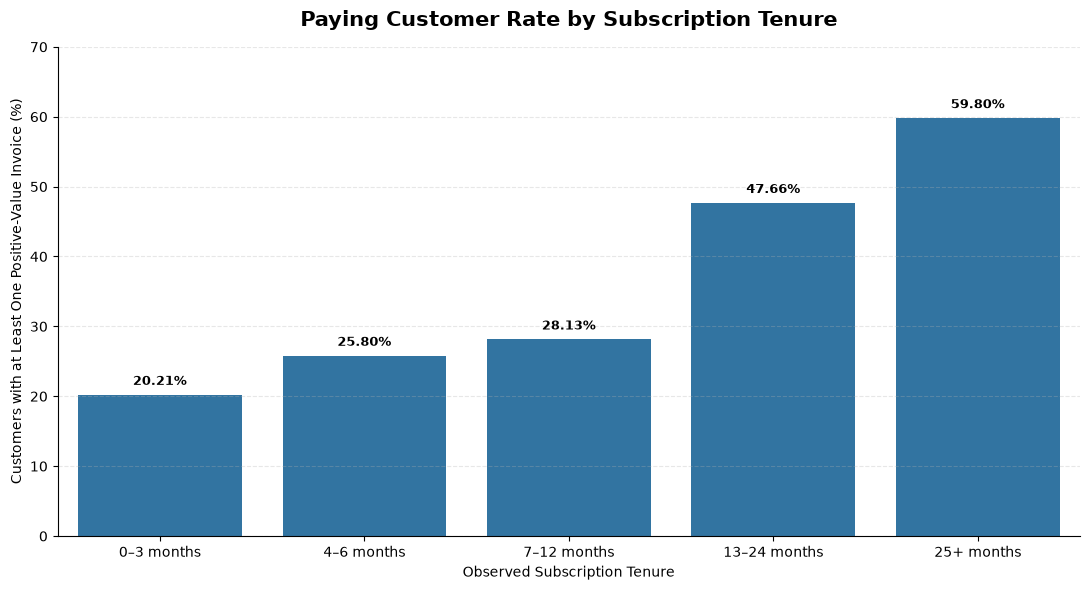

In [99]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=tenure_monetization,
    x="tenure_band",
    y="paying_customer_rate_pct",
    ax=ax
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=5,
        fontsize=9,
        fontweight="bold"
    )

ax.set_title(
    "Paying Customer Rate by Subscription Tenure",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Observed Subscription Tenure")
ax.set_ylabel("Customers with at Least One Positive-Value Invoice (%)")

ax.set_ylim(0, 70)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

sns.despine()

plt.tight_layout()

fig.savefig(
    "../outputs/figures/paying_customer_rate_by_tenure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

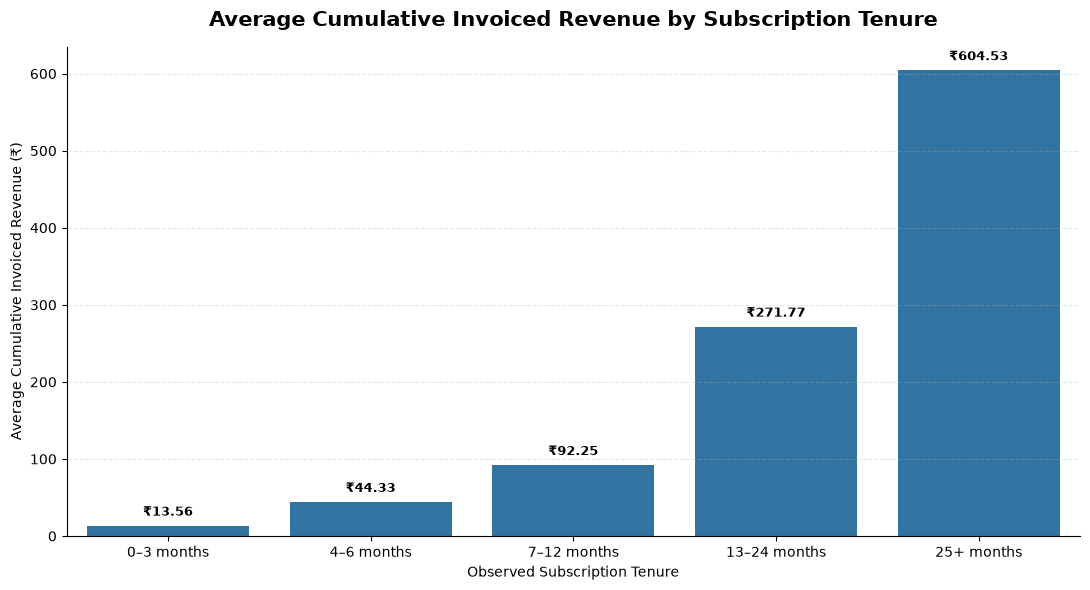

In [100]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=tenure_monetization,
    x="tenure_band",
    y="average_revenue",
    ax=ax
)

# Add revenue labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"₹{value:,.2f}"
            for value in tenure_monetization["average_revenue"]
        ],
        padding=5,
        fontsize=9,
        fontweight="bold"
    )

ax.set_title(
    "Average Cumulative Invoiced Revenue by Subscription Tenure",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Observed Subscription Tenure"
)

ax.set_ylabel(
    "Average Cumulative Invoiced Revenue (₹)"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

sns.despine()

plt.tight_layout()

fig.savefig(
    "../outputs/figures/average_revenue_by_tenure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 11.4 Customer Revenue by Subscription Plan

Compare customer-level cumulative revenue, paying-customer counts, and revenue per paying customer across subscription plans and billing cycles.

In [101]:
# Summarize customer-level cumulative revenue by plan
segment_revenue = (
    customer_revenue_analysis
    .groupby(
        ["plan_name", "billing_cycle"]
    )
    .agg(
        customers=("customer_id", "nunique"),
        paying_customers=("is_paying_customer", "sum"),
        total_revenue=("total_invoiced_revenue", "sum"),
        average_revenue=("total_invoiced_revenue", "mean"),
        median_revenue=("total_invoiced_revenue", "median")
    )
    .reset_index()
)

segment_revenue["paying_rate_pct"] = (
    segment_revenue["paying_customers"]
    / segment_revenue["customers"]
    * 100
).round(2)

segment_revenue[
    ["total_revenue", "average_revenue", "median_revenue"]
] = (
    segment_revenue[
        ["total_revenue", "average_revenue", "median_revenue"]
    ].round(2)
)

segment_revenue = segment_revenue.sort_values(
    "total_revenue",
    ascending=False
)

display(segment_revenue)

,plan_name,billing_cycle,customers,paying_customers,total_revenue,average_revenue,median_revenue,paying_rate_pct
4,Premium,monthly,785,747,908523.0,1157.35,891.0,95.16
6,Pro,monthly,1654,1585,903364.0,546.17,441.0,95.83
1,Basic,monthly,4867,3913,728802.0,149.74,114.0,80.40
3,Premium,annual,458,241,331650.0,724.13,990.0,52.62
5,Pro,annual,920,463,310170.0,337.14,490.0,50.33
0,Basic,annual,2129,1078,279680.0,131.37,190.0,50.63
2,Free,monthly,14187,0,0.0,0.00,0.0,0.00


In [102]:
# Calculate cumulative revenue per paying customer
segment_revenue["revenue_per_paying_customer"] = np.where(
    segment_revenue["paying_customers"] > 0,
    segment_revenue["total_revenue"]
    / segment_revenue["paying_customers"],
    0
)

segment_revenue["revenue_per_paying_customer"] = (
    segment_revenue["revenue_per_paying_customer"]
    .round(2)
)

display(
    segment_revenue[
        [
            "plan_name",
            "billing_cycle",
            "customers",
            "paying_customers",
            "paying_rate_pct",
            "average_revenue",
            "revenue_per_paying_customer"
        ]
    ]
)

,plan_name,billing_cycle,customers,paying_customers,paying_rate_pct,average_revenue,revenue_per_paying_customer
4,Premium,monthly,785,747,95.16,1157.35,1216.23
6,Pro,monthly,1654,1585,95.83,546.17,569.95
1,Basic,monthly,4867,3913,80.40,149.74,186.25
3,Premium,annual,458,241,52.62,724.13,1376.14
5,Pro,annual,920,463,50.33,337.14,669.91
0,Basic,annual,2129,1078,50.63,131.37,259.44
2,Free,monthly,14187,0,0.00,0.00,0.00


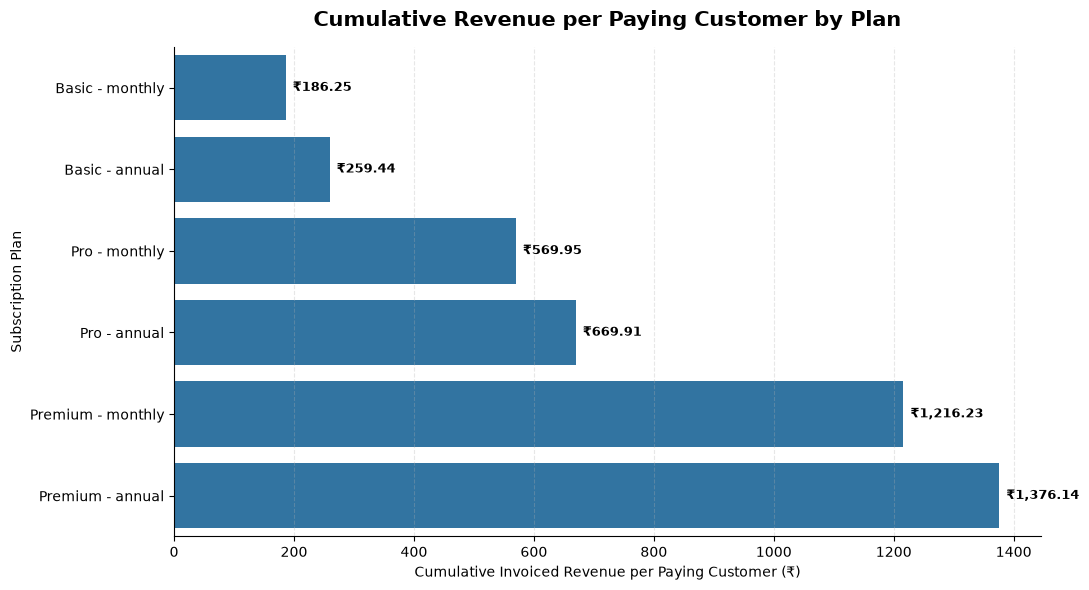

In [103]:
# Keep only paid subscription segments
revenue_per_paying_plot = (
    segment_revenue[
        segment_revenue["paying_customers"] > 0
    ]
    .copy()
)

# Create readable category
revenue_per_paying_plot["plan_category"] = (
    revenue_per_paying_plot["plan_name"]
    + " - "
    + revenue_per_paying_plot["billing_cycle"]
)

# Sort from lowest to highest
revenue_per_paying_plot = (
    revenue_per_paying_plot
    .sort_values(
        "revenue_per_paying_customer",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=revenue_per_paying_plot,
    x="revenue_per_paying_customer",
    y="plan_category",
    ax=ax
)

# Add currency labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"₹{value:,.2f}"
            for value
            in revenue_per_paying_plot[
                "revenue_per_paying_customer"
            ]
        ],
        padding=5,
        fontsize=9,
        fontweight="bold"
    )

ax.set_title(
    "Cumulative Revenue per Paying Customer by Plan",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Cumulative Invoiced Revenue per Paying Customer (₹)"
)

ax.set_ylabel(
    "Subscription Plan"
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

sns.despine()

plt.tight_layout()

fig.savefig(
    "../outputs/figures/revenue_per_paying_customer_by_plan.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 12. Executive KPI Summary

Summarize the key customer, churn, retention, revenue, payment, and plan-change metrics from the analysis into a single executive-level KPI table.

In [104]:
# Build the final executive KPI summary

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Active Customers",
        "Recorded Churned Customers",
        "Recorded Churn Percentage",
        "Average Monthly Churn Rate",
        "Median Observed Tenure",
        "12-Month Average Cohort Retention",
        "Total Invoiced Revenue",
        "Successful Payment Rate",
        "Customers with Positive-Value Invoice",
        "Cumulative Revenue per Paying Customer",
        "Recorded Plan-Change Rate"
    ],
    "Value": [
        f"{total_customers:,}",
        f"{active_customers:,}",
        f"{churned_customers:,}",
        f"{churned_pct:.2f}%",
        f"{average_churn_rate:.2f}%",
        f"{customer_master['tenure_months'].median():.0f} months",
        f"{checkpoint_summary.loc[checkpoint_summary['Checkpoint'] == 'Month 12', 'Average Retention (%)'].iloc[0]:.2f}%",
        f"₹{total_revenue:,.2f}",
        f"{payment_success_rate:.2f}%",
        f"{actual_paying_customers:,}",
        f"₹{revenue_per_actual_paying_customer:,.2f}",
        f"{plan_change_rate:.2f}%"
    ]
})

display(kpi_summary)

,KPI,Value
0,Total Customers,"25,000"
1,Active Customers,"15,243"
2,Recorded Churned Customers,"9,757"
3,Recorded Churn Percentage,39.03%
4,Average Monthly Churn Rate,4.17%
5,Median Observed Tenure,7 months
6,12-Month Average Cohort Retention,61.64%
7,Total Invoiced Revenue,"₹3,462,189.00"
8,Successful Payment Rate,92.99%
9,Customers with Positive-Value Invoice,"8,027"


## 13. Business Insights & Recommendations

Translate the analytical findings into concise business insights, practical recommendations, and clearly stated limitations of the analysis.

### 13.1 Key Business Insights

**1. Customer churn and retention**

The dataset contains 25,000 customers, of whom 9,757 are recorded as churned and 15,243 as active. The overall recorded churn proportion is 39.03%, while the average monthly churn rate across the observed period is 4.17%.

Cohort analysis shows that average retention declines with subscription age: 99.89% at Month 1, 91.17% at Month 3, 79.50% at Month 6, and 61.64% at Month 12.

**2. Subscription plan is strongly associated with churn**

Recorded churn differs substantially across subscription plan categories. The chi-square test found a statistically significant association between subscription plan category and recorded churn (p < 0.05), with Cramér's V = 0.3425.

Monthly and annual billing categories also show noticeably different recorded churn patterns. These results describe associations in the dataset and should not be interpreted as evidence that a particular plan or billing cycle causes or prevents churn.

**3. Acquisition channel shows little relationship with recorded churn**

Recorded churn percentages are very similar across ads, organic and referral channels. The chi-square test did not find a statistically significant association between acquisition channel and recorded churn (p = 0.9630; Cramér's V = 0.0017).

**4. Industry differences are relatively small**

Recorded churn varies only slightly across finance, health, retail and tech. The chi-square test was not statistically significant at the 5% level (p = 0.0567; Cramér's V = 0.0174).

**5. Revenue grows substantially over the observation period**

Total invoiced revenue is ₹3,462,189. Monthly invoiced revenue reached a maximum of ₹155,676 in November 2025. Monthly revenue growth also showed notable movements, including a 56.03% increase in January 2024 and a 33.77% decline in January 2025.

The January 2024 increase coincided with higher annual as well as monthly invoicing. The January 2025 decline was associated with the absence of annual invoices, despite monthly invoice revenue increasing.

**6. Payment performance is relatively stable across plans**

Overall payment transaction success was 92.99%. Payment failure rates across the six paid plan categories ranged from 6.27% to 7.81%.

The chi-square test found no statistically significant association between subscription plan category and payment outcome (p = 0.8367; Cramér's V = 0.0055).

**7. Free-to-Basic conversion is the only recorded plan transition**

All 787 recorded plan changes were Free → Basic. This represents 3.15% of the total customer base. The median time from signup to the recorded plan change was 183 days, while the mean was 234.41 days.

**8. Longer observed tenure is associated with higher cumulative revenue**

Customers with longer observed subscription tenure show higher paying-customer rates and higher cumulative invoiced revenue. The Spearman correlation between observed tenure and cumulative invoiced revenue was 0.3491 (p < 0.05).

This relationship should be interpreted carefully because customers with longer tenure have had more time to accumulate invoices.

### 13.2 Business Recommendations

**1. Investigate plan-level retention differences**

The strong association between subscription plan category and recorded churn suggests that plan-level customer behavior should be investigated further. Retention analysis should consider plan type, billing cycle, tenure and customer characteristics together rather than relying on plan-level churn percentages alone.

**2. Focus retention analysis on early customer lifecycle stages**

Cohort retention declines substantially as subscription age increases. The business could therefore examine the customer journey during the first 3, 6 and 12 months to identify where retention losses are concentrated.

**3. Monitor payment failures by plan, but avoid over-interpreting small differences**

Payment failure rates are relatively similar across plan categories, and statistical testing did not find a meaningful association. Payment monitoring should therefore focus on individual failed transactions and operational resolution rather than assuming that one plan category has systematically worse payment performance.

**4. Treat acquisition-channel differences cautiously**

Since churn percentages and statistical results are very similar across acquisition channels, acquisition source alone should not be used as a strong explanation for customer churn in this dataset. Additional customer characteristics would be needed for deeper segmentation.

**5. Investigate annual billing and revenue timing**

The revenue analysis shows substantial month-to-month movements associated with invoice composition. Revenue reporting should therefore distinguish monthly and annual billing so that billing-cycle timing is not mistaken for underlying changes in customer demand.

**6. Use customer tenure as a key segmentation variable**

Longer-tenured customers show higher monetization levels in this dataset. Customer-lifecycle reporting should therefore track tenure alongside revenue, payment activity and retention.

### 13.3 Analytical Limitations

This project uses a synthetic SaaS subscription dataset. The results describe patterns within this dataset and should not be interpreted as industry benchmarks.

Recorded churn percentages are not equivalent to monthly or annual churn rates. Cumulative revenue measures are affected by customer observation time, and relationships identified through statistical tests represent association rather than causation.

Active customers are observed only up to the dataset observation cutoff of 31 December 2025, while invoice and payment records extend through November 2025.